# Intermitência renovável, despacho hidrotérmico e equilíbrio locacional (v2)

**Versão refatorada** do notebook 06, em alinhamento com o paper
"Mean Field Games in Renewable Energy Markets" e com os critérios
de consistência conceitual e reprodutibilidade abaixo.

## Glossário de notação

### Carga × demanda
- `L_RB`        — carga física da Rede Básica observada (MW).
- `G_MMGD`      — geração distribuída (mini/micro geração) (MW).
- `L_global`    — carga global do sistema: `L_global = L_RB + G_MMGD`.
- `L_net_s`     — carga líquida após solar: `L_net_s = L_global − G_s_total`.
- `L_res`       — carga residual após solar e eólica: `L_res = L_global − G_s_total − G_w_total`.
- `dL_res`      — rampa horária da carga residual.
- `D`           — reservado para *demanda econômica abstrata* (não usado aqui).

> Os campos `D_global`, `D_net`, `D_res` aparecem apenas como *aliases deprecated*.

### Preços
- `CMO_obs`     — Custo Marginal de Operação observado/divulgado (R$/MWh).
- `PLD_obs`     — Preço de Liquidação das Diferenças oficial (NaN, não disponível na base).
- `PLD_hat`     — Proxy de PLD obtido por clipping do CMO nos tetos regulatórios.
- `lambda_model` — Preço-sombra (multiplicador do balanço energético) dos modelos de otimização.
  *Nunca chamamos `lambda_model` de CMO ou PLD.*

### Capacidades
- `K_s_eff_p99`, `K_w_eff_p99`, `K_h_eff_p99`, `K_n_eff_p99` — capacidades
  EFETIVAS estimadas via p99 da geração horária (proxy, não capacidade instalada oficial).
- `K_s_inst` etc. — reservados para capacidade instalada oficial (não usado por falta de fonte canônica).

### Hidrologia
- Hidrologia é **proxy**: usamos afluência, geração observada e `vol_util_pct`.
- Cota montante, cota jusante e vazão turbinada não estão disponíveis na granularidade necessária.
- A fórmula física é apresentada apenas como referência.

### Modelo locacional
- O bloco "MFG locacional" é chamado de **modelo locacional inspirado em MFG**
  (clearing locacional + iteração de preços), e *não* de MFG completo, pois não
  resolvemos explicitamente a distribuição populacional `m`, estado individual,
  política ótima e equação forward em conjunto.


## 0. Setup, imports e diretórios de saída

Sem caminhos absolutos: detectamos o root do projeto procurando o diretório `validate_model/` a partir de `Path.cwd()`.

In [1]:
from __future__ import annotations
import os, sys, math, json, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import cvxpy as cp

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140,
    "axes.titleweight": "bold",
    "axes.spines.right": False, "axes.spines.top": False,
    "font.size": 10,
})


def _find_project_root(start: Path | None = None, marker: str = "validate_model") -> Path:
    """Sobe a árvore a partir de `start` (default: cwd) procurando o marcador."""
    cur = Path(start or Path.cwd()).resolve()
    for cand in [cur, *cur.parents]:
        if (cand / marker).exists():
            return cand
    return cur


ROOT   = _find_project_root()
DATA   = ROOT / "validate_model" / "data"
OUT    = ROOT / "outputs"
FIGS   = OUT / "figures"
TABLES = OUT / "tables"
CACHE  = OUT / "cache"
for d in (OUT, FIGS, TABLES, CACHE):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
from validate_model.pipeline import (
    SINPaths, build_panel, load_cmo_horario, load_hidrologia,
    canonical_subsys,
)

print(f"ROOT   : {ROOT}")
print(f"OUT    : {OUT}")
print(f"cvxpy  : {cp.__version__}")
print(f"pandas : {pd.__version__}")


ROOT   : C:\Users\joaof\Mean-Field-Games-in-Renewable-Energy
OUT    : C:\Users\joaof\Mean-Field-Games-in-Renewable-Energy\outputs
cvxpy  : 1.7.5
pandas : 2.3.0


## 1. Painel SIN, CMO horário e hidrologia (cache)

In [2]:
DATE_MIN = pd.Timestamp("2025-01-01 00:00:00")
DATE_MAX = pd.Timestamp("2025-10-31 23:00:00")

SUBSYS_ORDER = ["N", "NE", "SE", "S"]
SUB_LABEL = {"N": "Norte", "NE": "Nordeste", "SE": "Sudeste/CO", "S": "Sul"}
SUB_COLOR = {"N": "#1f77b4", "NE": "#d62728", "SE": "#2ca02c", "S": "#9467bd"}

PANEL_CACHE = CACHE / "panel_hourly_v2.parquet"
CMO_CACHE   = CACHE / "cmo_hourly_v2.parquet"
HYDRO_CACHE = CACHE / "hidrologia_v2.parquet"

paths = SINPaths(root=str(ROOT / "validate_model"), year=2025)

if PANEL_CACHE.exists():
    panel = pd.read_parquet(PANEL_CACHE)
    print(f"[CACHE] painel: {len(panel):,} linhas")
else:
    panel = build_panel(paths)
    panel.to_parquet(PANEL_CACHE, index=False)

if CMO_CACHE.exists():
    cmo = pd.read_parquet(CMO_CACHE)
else:
    cmo = load_cmo_horario(paths.cmo_semihorario_path)
    cmo.to_parquet(CMO_CACHE, index=False)

if HYDRO_CACHE.exists():
    hydro = pd.read_parquet(HYDRO_CACHE)
else:
    hydro = load_hidrologia(paths.hidro_di_path)
    hydro.to_parquet(HYDRO_CACHE, index=False)

panel = panel[(panel["din_instante"] >= DATE_MIN) & (panel["din_instante"] <= DATE_MAX)].copy()
cmo   = cmo[(cmo["din_instante"] >= DATE_MIN) & (cmo["din_instante"] <= DATE_MAX)].copy()
hydro = hydro[(hydro["din_instante"] >= DATE_MIN) & (hydro["din_instante"] <= DATE_MAX)].copy()

print(f"Painel : {len(panel):>10,} | {panel['din_instante'].min()} -> {panel['din_instante'].max()}")
print(f"CMO    : {len(cmo):>10,}  | {cmo['din_instante'].min()}   -> {cmo['din_instante'].max()}")
print(f"Hidro  : {len(hydro):>10,}  | {hydro['din_instante'].min()} -> {hydro['din_instante'].max()}")


[CACHE] painel: 29,664 linhas
Painel :     29,184 | 2025-01-01 00:00:00 -> 2025-10-31 23:00:00
CMO    :     29,088  | 2025-01-01 00:00:00   -> 2025-10-31 23:00:00
Hidro  :        304  | 2025-01-01 00:00:00 -> 2025-10-31 00:00:00


## 2. Calendário (estação, tipo de dia)

In [3]:
SOUTH_HEMI_SEASON = {
    12: "verao", 1: "verao", 2: "verao",
    3: "outono", 4: "outono", 5: "outono",
    6: "inverno", 7: "inverno", 8: "inverno",
    9: "primavera", 10: "primavera", 11: "primavera",
}
SEASON_ORDER = ["verao", "outono", "inverno", "primavera"]
FERIADOS_2025 = {
    "2025-01-01", "2025-03-03", "2025-03-04", "2025-04-18",
    "2025-04-21", "2025-05-01", "2025-06-19", "2025-09-07",
    "2025-10-12", "2025-11-02", "2025-11-15", "2025-11-20",
    "2025-12-25",
}


def add_calendar(df: pd.DataFrame, dt_col: str = "din_instante") -> pd.DataFrame:
    df = df.copy()
    t = df[dt_col]
    df["data"]       = t.dt.date
    df["ano"]        = t.dt.year
    df["mes"]        = t.dt.month
    df["dia_semana"] = t.dt.dayofweek
    df["hora"]       = t.dt.hour
    df["estacao"]    = df["mes"].map(SOUTH_HEMI_SEASON)
    feriados = pd.to_datetime(list(FERIADOS_2025)).date
    is_feriado = df["data"].isin(feriados)
    df["tipo_dia"] = np.select(
        [is_feriado, df["dia_semana"] == 5, df["dia_semana"] == 6],
        ["feriado", "sabado", "domingo"],
        default="util",
    )
    df["tipo_dia_g"] = np.where(df["tipo_dia"] == "util", "util", "fim_semana_feriado")
    return df


panel = add_calendar(panel)
cmo   = add_calendar(cmo)
print(panel.groupby("estacao", observed=False).size().reindex(SEASON_ORDER))


estacao
verao        5664
outono       8832
inverno      8832
primavera    5856
dtype: int64


## 3. Definição das variáveis de **carga** (`L`) — não `D`

- `L_RB`     = carga da Rede Básica observada (campo `D` original do painel).
- `G_MMGD`   = geração distribuída (solar MMGD).
- `L_global` = `L_RB + G_MMGD`.
- `L_net_s`  = `L_global − G_s_total`.
- `L_res`    = `L_global − G_s_total − G_w_total`.
- `dL_res`   = rampa horária de `L_res`.

`D_global`, `D_net`, `D_res` permanecem apenas como aliases para compatibilidade
com código legado.


In [4]:
print("Re-lendo solar para isolar MMGD vs centralizada...")
sol_raw = pd.read_csv(paths.solar_path, sep=";", parse_dates=["din_instante"])
sol_raw["din_instante"] = sol_raw["din_instante"].dt.floor("h")
sol_raw["id_subsistema"] = sol_raw["nom_subsistema"].astype(str).map(canonical_subsys)
sol_raw = sol_raw[(sol_raw["din_instante"] >= DATE_MIN) & (sol_raw["din_instante"] <= DATE_MAX)]
is_mmgd = sol_raw["cod_modalidadeoperacao"].astype(str).str.contains("MMGD", case=False, regex=False)

sol_mmgd = (sol_raw[is_mmgd]
    .groupby(["din_instante", "id_subsistema"], as_index=False)["val_geracao"].sum()
    .rename(columns={"val_geracao": "G_MMGD"}))
sol_cen = (sol_raw[~is_mmgd]
    .groupby(["din_instante", "id_subsistema"], as_index=False)["val_geracao"].sum()
    .rename(columns={"val_geracao": "G_s_total"}))

panel = (panel
    .merge(sol_mmgd, on=["din_instante", "id_subsistema"], how="left")
    .merge(sol_cen,  on=["din_instante", "id_subsistema"], how="left"))
panel["G_MMGD"]    = panel["G_MMGD"].fillna(0.0)
panel["G_s_total"] = panel["G_s_total"].fillna(0.0)
panel["G_w_total"] = panel["gr"].fillna(0.0)
panel["G_h_total"] = panel["gh"].fillna(0.0)
panel["G_n_total"] = panel["g_nuc_obs"].fillna(0.0) + panel["g_th_obs"].fillna(0.0)

# Renomeia D (Rede Básica) -> L_RB e define variantes de carga
panel = panel.rename(columns={"D": "L_RB"})
panel["L_RB"]     = pd.to_numeric(panel["L_RB"], errors="coerce")
panel["L_global"] = panel["L_RB"] + panel["G_MMGD"]
panel["L_net_s"]  = panel["L_global"] - panel["G_s_total"]
panel["L_res"]    = panel["L_global"] - panel["G_s_total"] - panel["G_w_total"]

# Aliases DEPRECATED — manter por compatibilidade com código antigo
panel["D_global"] = panel["L_global"]   # deprecated
panel["D_net"]    = panel["L_net_s"]    # deprecated
panel["D_res"]    = panel["L_res"]      # deprecated

panel = panel.sort_values(["id_subsistema", "din_instante"]).reset_index(drop=True)
panel["dL_res"]   = panel.groupby("id_subsistema")["L_res"].diff()
panel["dL_net_s"] = panel.groupby("id_subsistema")["L_net_s"].diff()

print(f"\nLinhas finais     : {len(panel):,}")
print(f"Subsistemas       : {sorted(panel['id_subsistema'].dropna().unique())}")
print(f"Horizonte temporal: {panel['din_instante'].min()} -> {panel['din_instante'].max()}")

panel.groupby("id_subsistema").agg(
    L_RB_mean=("L_RB", "mean"),
    L_global_mean=("L_global", "mean"),
    L_res_mean=("L_res", "mean"),
    Gs_mean=("G_s_total", "mean"),
    Gw_mean=("G_w_total", "mean"),
    Gh_mean=("G_h_total", "mean"),
).round(1)


Re-lendo solar para isolar MMGD vs centralizada...

Linhas finais     : 29,184
Subsistemas       : ['N', 'NE', 'S', 'SE']
Horizonte temporal: 2025-01-01 00:00:00 -> 2025-10-31 23:00:00


,L_RB_mean,L_global_mean,L_res_mean,Gs_mean,Gw_mean,Gh_mean
id_subsistema,,,,,,
N,8213.0,8788.6,8594.8,1.2,196.3,8128.9
NE,13177.3,14463.9,105.3,1936.8,12490.5,3222.5
S,13769.5,14977.6,14275.7,0.7,703.3,7963.3
SE,44111.5,47489.7,45802.8,1682.0,5.7,27104.9


## 4. Auditoria de cobertura dos dados

Tabela `dataset, min_datetime, max_datetime, n_obs, missing_rate`,
salva em `outputs/tables/tab_coverage_data.csv`, com identificação
do período comum válido às séries.


In [5]:
def audit_dataset(name: str, df: pd.DataFrame, dt_col: str = "din_instante") -> dict | None:
    if dt_col not in df.columns:
        return None
    t = pd.to_datetime(df[dt_col], errors="coerce").dropna()
    if len(t) == 0:
        return {"dataset": name, "min_datetime": None, "max_datetime": None,
                "n_obs": 0, "missing_rate": np.nan}
    num = df.select_dtypes(include=[np.number]).columns.tolist()
    miss = float(df[num].isna().mean().mean()) if num else np.nan
    return {"dataset": name, "min_datetime": str(t.min()),
            "max_datetime": str(t.max()), "n_obs": int(len(df)),
            "missing_rate": miss}


records = []
for name, df in [("panel_SIN", panel), ("cmo_horario", cmo),
                 ("hidrologia_diaria", hydro), ("solar_raw", sol_raw)]:
    rec = audit_dataset(name, df)
    if rec:
        records.append(rec)
tab_cov = pd.DataFrame(records)
tab_cov.to_csv(TABLES / "tab_coverage_data.csv", index=False)
print("Cobertura dos datasets:")
print(tab_cov.to_string(index=False))

valid_mins = [pd.Timestamp(r["min_datetime"]) for r in records if r["min_datetime"]]
valid_maxs = [pd.Timestamp(r["max_datetime"]) for r in records if r["max_datetime"]]
if valid_mins and valid_maxs:
    common_min = max(valid_mins)
    common_max = min(valid_maxs)
    print(f"\nPeríodo comum válido às séries: {common_min} -> {common_max}")


Cobertura dos datasets:
          dataset        min_datetime        max_datetime  n_obs  missing_rate
        panel_SIN 2025-01-01 00:00:00 2025-10-31 23:00:00  29184      0.006917
      cmo_horario 2025-01-01 00:00:00 2025-10-31 23:00:00  29088      0.000000
hidrologia_diaria 2025-01-01 00:00:00 2025-10-31 00:00:00    304      0.000000
        solar_raw 2025-01-01 00:00:00 2025-10-31 23:00:00 841440      0.000342

Período comum válido às séries: 2025-01-01 00:00:00 -> 2025-10-31 00:00:00


## 5. Capacidades **efetivas** (proxy p99) — `K_*_eff_p99`

Os valores abaixo são proxies obtidos pelo percentil 99 da geração horária
em 2025. **Não** são capacidades instaladas oficiais (`K_s_inst`, etc.).
Capacidades oficiais não foram alimentadas aqui pela ausência de fonte
canônica nos dados fornecidos.


In [6]:
K_eff = (panel.groupby("id_subsistema")
    .agg(
        K_s_eff_p99=("G_s_total", lambda x: float(np.nanquantile(x, 0.99))),
        K_w_eff_p99=("G_w_total", lambda x: float(np.nanquantile(x, 0.99))),
        K_h_eff_p99=("G_h_total", lambda x: float(np.nanquantile(x, 0.99))),
        K_n_eff_p99=("G_n_total", lambda x: float(np.nanquantile(x, 0.99))),
    ).reindex(SUBSYS_ORDER))
K_eff.to_csv(TABLES / "tab_capacidades_efetivas_p99.csv", float_format="%.1f")
print("Capacidades EFETIVAS proxy (p99 horário, MW). NÃO são capacidade instalada oficial:")
print(K_eff.round(0).to_string())

# Fatores de capacidade observados (a_s, a_w)
for gcol, kcol in [("G_s_total", "K_s_eff_p99"), ("G_w_total", "K_w_eff_p99")]:
    a = panel[gcol] / panel["id_subsistema"].map(K_eff[kcol])
    panel[f"a_{gcol}"] = a.clip(lower=0.0, upper=1.5)
print("\nFator de capacidade médio observado:")
print(panel.groupby("id_subsistema")[["a_G_s_total", "a_G_w_total"]].mean().round(3).to_string())


Capacidades EFETIVAS proxy (p99 horário, MW). NÃO são capacidade instalada oficial:
               K_s_eff_p99  K_w_eff_p99  K_h_eff_p99  K_n_eff_p99
id_subsistema                                                    
N                      4.0        411.0      18806.0       3446.0
NE                  7159.0      21870.0       6373.0       2972.0
SE                  6305.0         16.0      45312.0       9992.0
S                      2.0       1853.0      15249.0       2065.0

Fator de capacidade médio observado:
               a_G_s_total  a_G_w_total
id_subsistema                          
N                    0.300        0.477
NE                   0.271        0.571
S                    0.332        0.380
SE                   0.267        0.353


## 6. Perfis horários: `L_global`, `L_RB`, `L_res` por estação × tipo_dia (Figura 1)

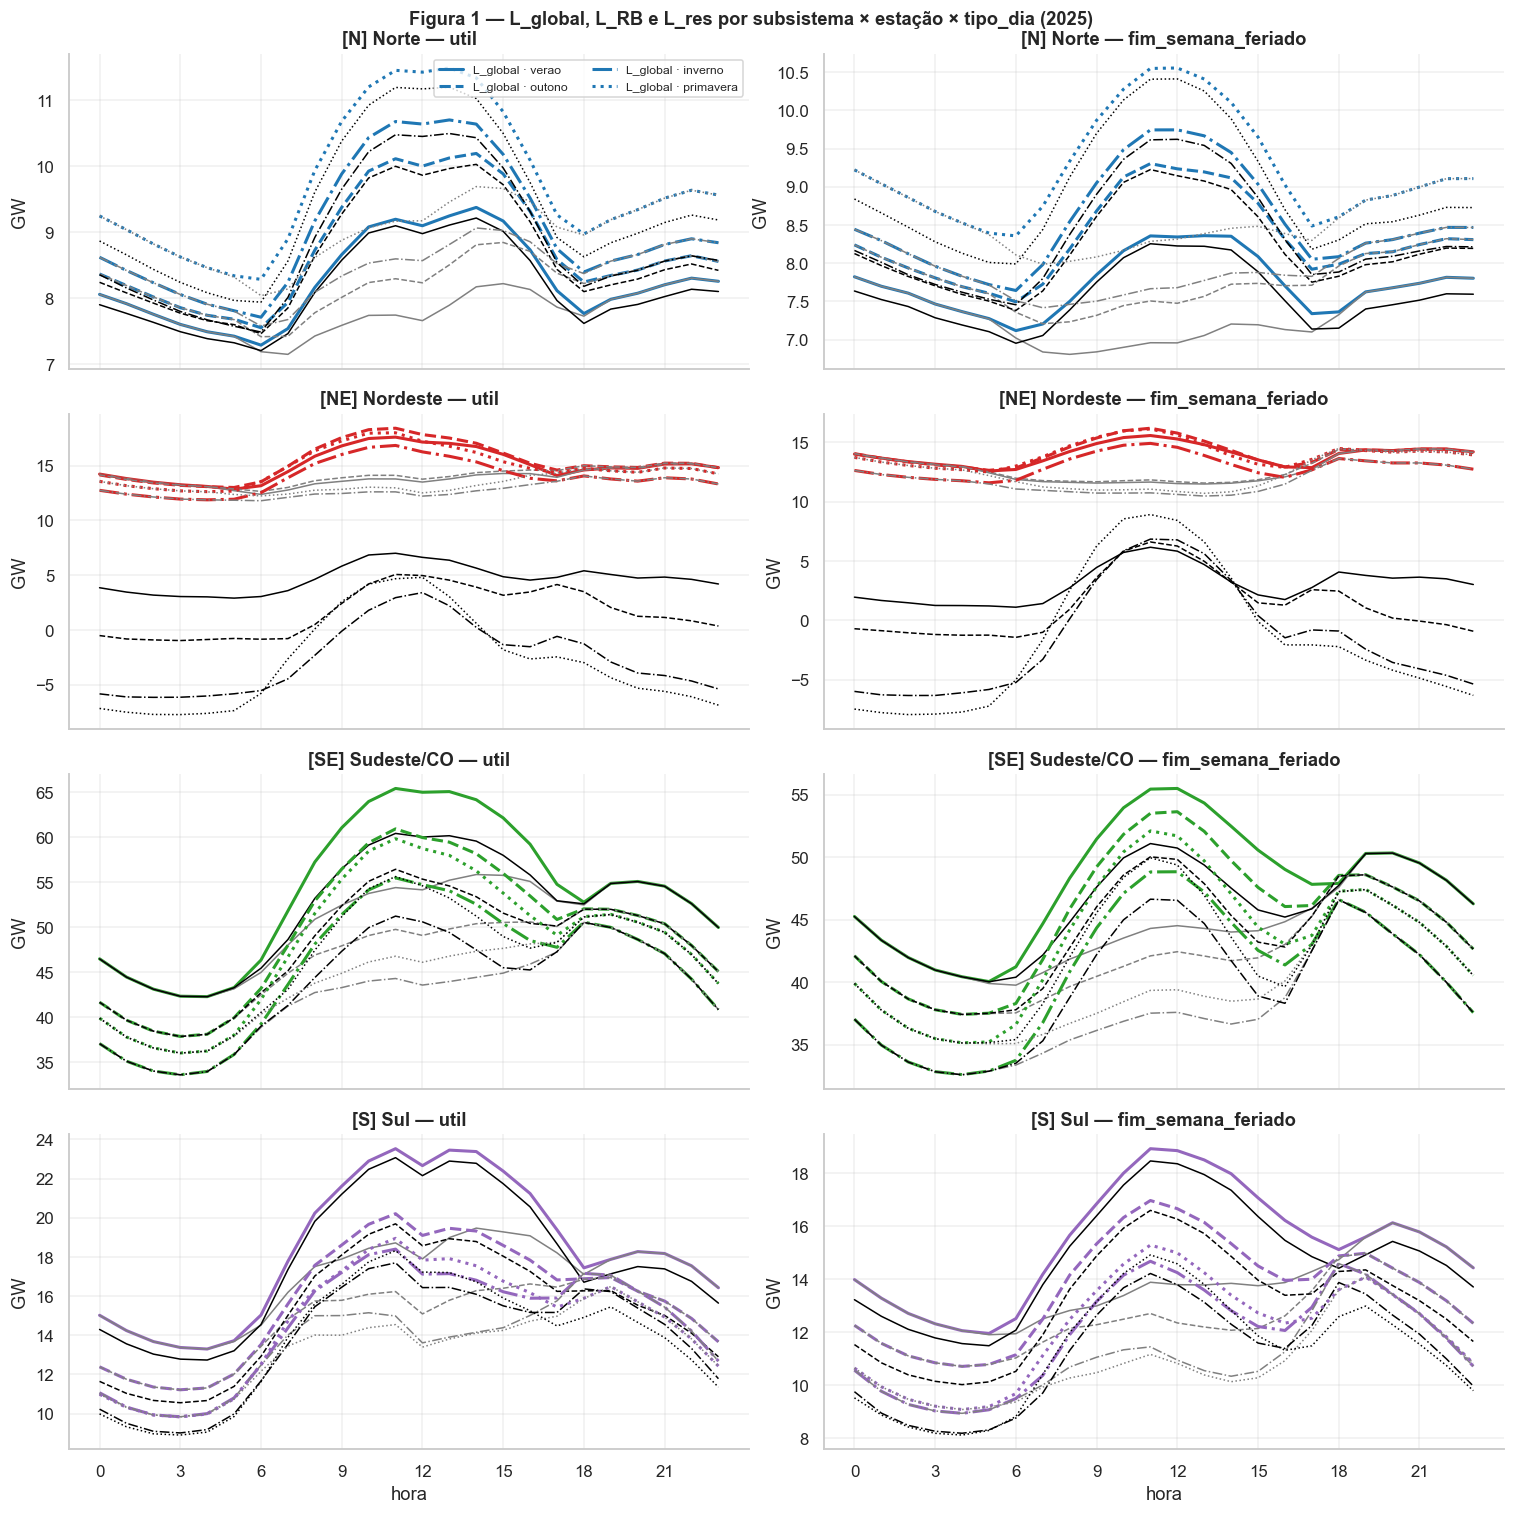

In [7]:
def avg_profile(df: pd.DataFrame, cols: list[str],
                by=("id_subsistema", "estacao", "tipo_dia_g", "hora")) -> pd.DataFrame:
    return df.groupby(list(by), observed=False)[list(cols)].mean().reset_index()


prof = avg_profile(panel, ["L_global", "L_RB", "L_res", "G_s_total", "G_w_total", "G_h_total"])
prof.to_csv(TABLES / "tab_perfis_horarios_carga.csv", index=False, float_format="%.1f")

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for j, td in enumerate(["util", "fim_semana_feriado"]):
    for i, sub in enumerate(SUBSYS_ORDER):
        ax = axes[i, j]
        for est, ls in zip(SEASON_ORDER, ["-", "--", "-.", ":"]):
            g = prof.query("id_subsistema == @sub and estacao == @est and tipo_dia_g == @td")
            if len(g) == 0: continue
            ax.plot(g["hora"], g["L_global"]/1000, color=SUB_COLOR[sub], ls=ls, lw=2,
                    label=f"L_global · {est}")
            ax.plot(g["hora"], g["L_RB"]/1000,  color="gray",  ls=ls, lw=1)
            ax.plot(g["hora"], g["L_res"]/1000, color="black", ls=ls, lw=1)
        ax.set_title(f"[{sub}] {SUB_LABEL[sub]} — {td}")
        ax.set_ylabel("GW")
        ax.set_xticks(range(0, 24, 3))
        ax.grid(alpha=.3)
axes[0, 0].legend(fontsize=8, ncols=2, loc="upper right")
axes[-1, 0].set_xlabel("hora"); axes[-1, 1].set_xlabel("hora")
fig.suptitle("Figura 1 — L_global, L_RB e L_res por subsistema × estação × tipo_dia (2025)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "fig01_carga_global_rb_res.png", bbox_inches="tight")
plt.show()


## 7. Diagnóstico operacional: hora de mínimo de `L_res`, rampa máxima `|dL_res|`, excedente (Figura 2)

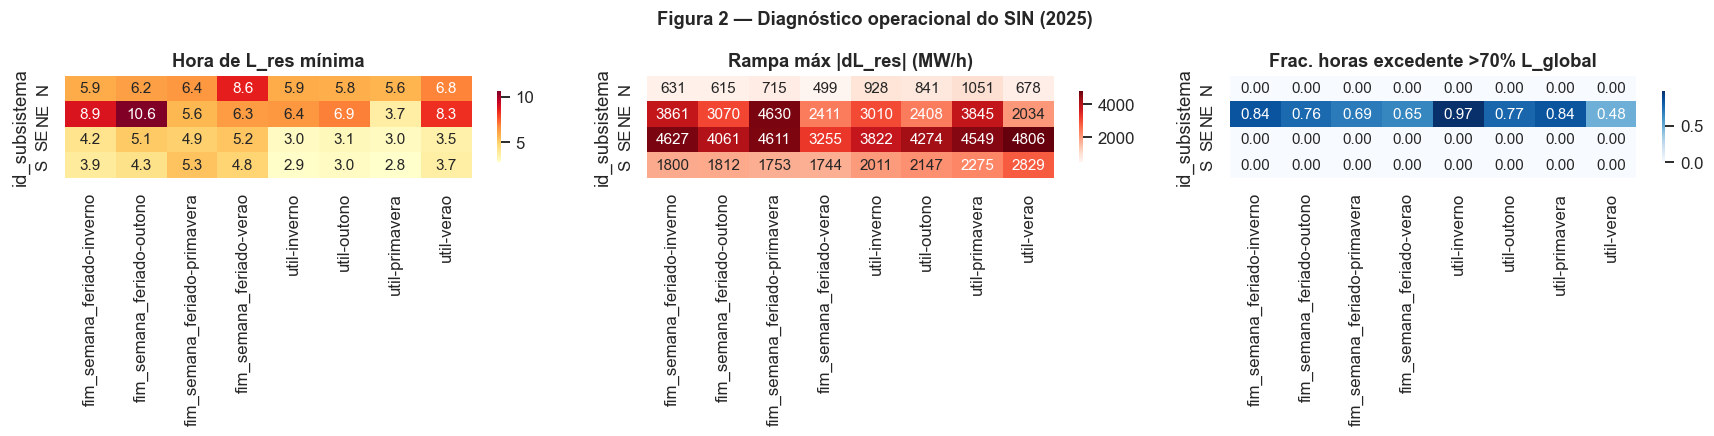

In [8]:
ag = panel.groupby(["id_subsistema", "estacao", "tipo_dia_g", "data"])
hora_min = ag.apply(
    lambda x: x.loc[x["L_res"].idxmin(), "hora"] if x["L_res"].notna().any() else np.nan,
    include_groups=False).reset_index(name="hora_min_L_res")
hora_min_avg = (hora_min.groupby(["id_subsistema", "estacao", "tipo_dia_g"])["hora_min_L_res"]
                .mean().reset_index())

ramp = ag["dL_res"].apply(lambda x: x.abs().max()).reset_index(name="rampa_max_dL_res")
ramp_avg = (ramp.groupby(["id_subsistema", "estacao", "tipo_dia_g"])["rampa_max_dL_res"]
            .mean().reset_index())

d = panel.copy()
d["pot_exc"] = ((d["G_s_total"] + d["G_w_total"]) > 0.7 * d["L_global"]).astype(int)
exc = d.groupby(["id_subsistema", "estacao", "tipo_dia_g"])["pot_exc"].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def heatmap(df, val, title, ax, fmt=".1f", cmap="viridis"):
    piv = (df.pivot_table(index="id_subsistema", columns=["tipo_dia_g", "estacao"], values=val)
              .reindex(index=SUBSYS_ORDER))
    sns.heatmap(piv, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar_kws={"shrink": .7})
    ax.set_title(title); ax.set_xlabel("")

heatmap(hora_min_avg, "hora_min_L_res",     "Hora de L_res mínima",      axes[0], fmt=".1f", cmap="YlOrRd")
heatmap(ramp_avg,     "rampa_max_dL_res",   "Rampa máx |dL_res| (MW/h)", axes[1], fmt=".0f", cmap="Reds")
heatmap(exc,          "pot_exc",            "Frac. horas excedente >70% L_global", axes[2], fmt=".2f", cmap="Blues")
fig.suptitle("Figura 2 — Diagnóstico operacional do SIN (2025)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "fig02_diagnostico_operacional.png", bbox_inches="tight")
plt.show()


## 8. Curva do pato e contrafactual de expansão solar (Figura 4)

`L_net_s(α) = L_global − α · G_s_total` para `α ∈ {1, 1.5, 2, 3}`.


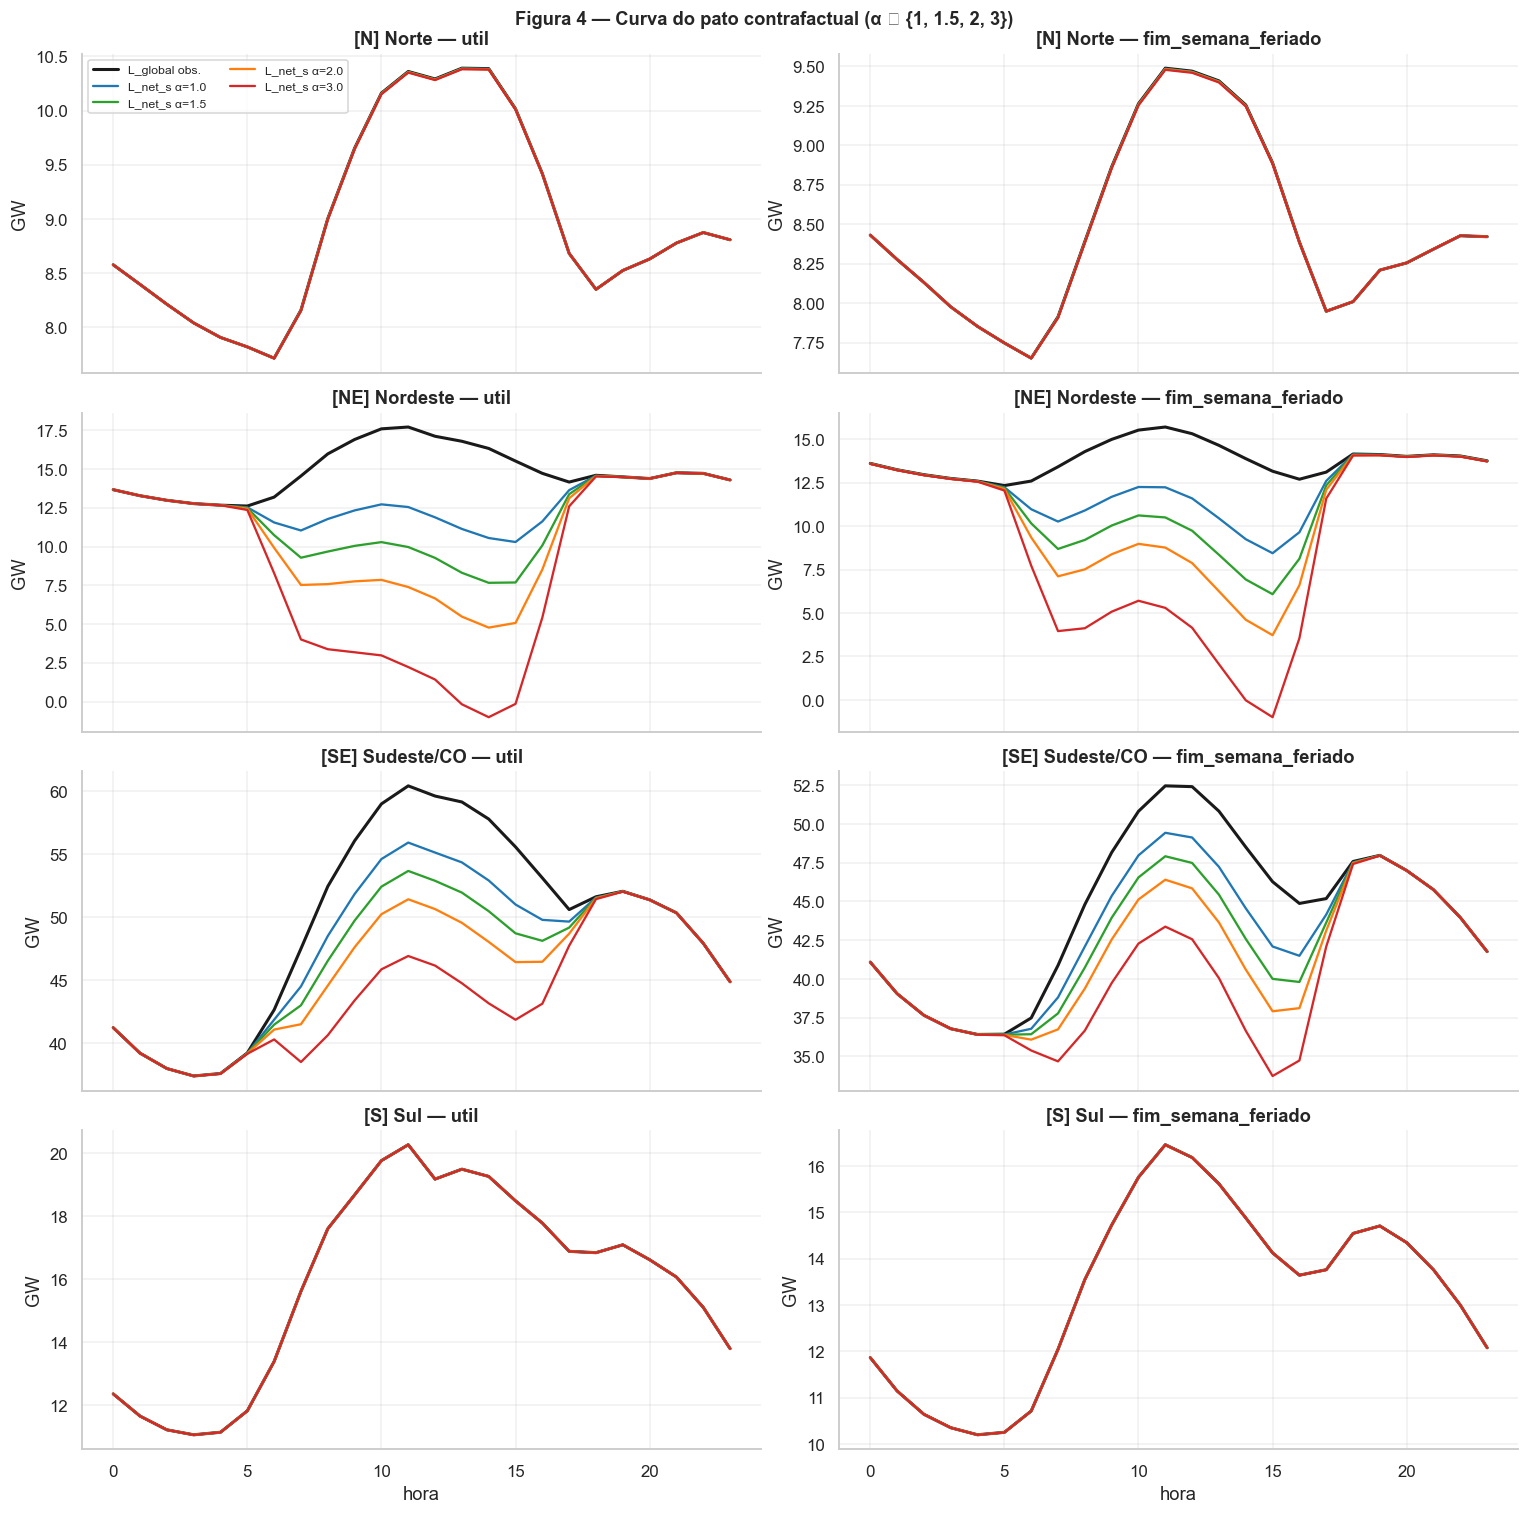

In [9]:
ALPHAS = [1.0, 1.5, 2.0, 3.0]
typ = panel.groupby(["id_subsistema", "estacao", "tipo_dia_g", "hora"], observed=False).agg(
    L_global=("L_global", "mean"),
    G_s_total=("G_s_total", "mean"),
    G_w_total=("G_w_total", "mean"),
    G_h_total=("G_h_total", "mean"),
).reset_index()

ramp_rows = []
for alpha in ALPHAS:
    typ[f"L_net_s_a{alpha}"] = typ["L_global"] - alpha * typ["G_s_total"]
    typ[f"dL_net_s_a{alpha}"] = (typ.sort_values("hora")
        .groupby(["id_subsistema", "estacao", "tipo_dia_g"])[f"L_net_s_a{alpha}"].diff())
    r = (typ.groupby(["id_subsistema", "estacao", "tipo_dia_g"])[f"dL_net_s_a{alpha}"]
            .agg(rampa_max_pos="max", rampa_max_neg="min").reset_index())
    r["alpha"] = alpha
    ramp_rows.append(r)
ramp_summary = pd.concat(ramp_rows, ignore_index=True)
ramp_summary.to_csv(TABLES / "tab_rampa_por_alpha.csv", index=False, float_format="%.0f")

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for j, td in enumerate(["util", "fim_semana_feriado"]):
    for i, sub in enumerate(SUBSYS_ORDER):
        ax = axes[i, j]
        g = typ.query("id_subsistema == @sub and tipo_dia_g == @td")
        gp = g.groupby("hora").mean(numeric_only=True).reset_index()
        ax.plot(gp["hora"], gp["L_global"]/1000, "k-", lw=2, label="L_global obs.")
        for alpha, col in zip(ALPHAS, ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]):
            ax.plot(gp["hora"], gp[f"L_net_s_a{alpha}"]/1000, color=col, lw=1.5,
                    label=f"L_net_s α={alpha}")
        ax.set_title(f"[{sub}] {SUB_LABEL[sub]} — {td}")
        ax.set_ylabel("GW"); ax.grid(alpha=.3)
axes[0, 0].legend(fontsize=8, ncols=2)
axes[-1, 0].set_xlabel("hora"); axes[-1, 1].set_xlabel("hora")
fig.suptitle("Figura 4 — Curva do pato contrafactual (α ∈ {1, 1.5, 2, 3})",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "fig04_curva_pato_contrafactual.png", bbox_inches="tight")
plt.show()


## 9. Preços: `CMO_obs`, `PLD_obs`, `PLD_hat`, e mais tarde `lambda_model`

- `CMO_obs`: observado/divulgado pelo ONS/CCEE.
- `PLD_obs`: oficial CCEE — NaN aqui (não fornecido na base).
- `PLD_hat`: proxy de PLD via *clipping* do CMO nos tetos regulatórios 2025
  (PLD_min = 65.69 R$/MWh; PLD_max = 939.96 R$/MWh).
- `lambda_model`: preço-sombra dos modelos de otimização (NÃO chamar de CMO ou PLD).


Estatísticas de CMO_obs e PLD_hat por subsistema (R$/MWh):
              CMO_obs                   PLD_hat                  
                 mean    std <lambda_0>    mean    std <lambda_0>
id_subsistema                                                    
N               139.8  137.2      340.3   166.2  112.9      340.3
NE              127.0  134.0      333.6   156.5  108.0      333.6
S               215.0  132.3      368.7   226.2  113.6      368.7
SE              202.7  134.0      365.4   215.3  114.4      365.4


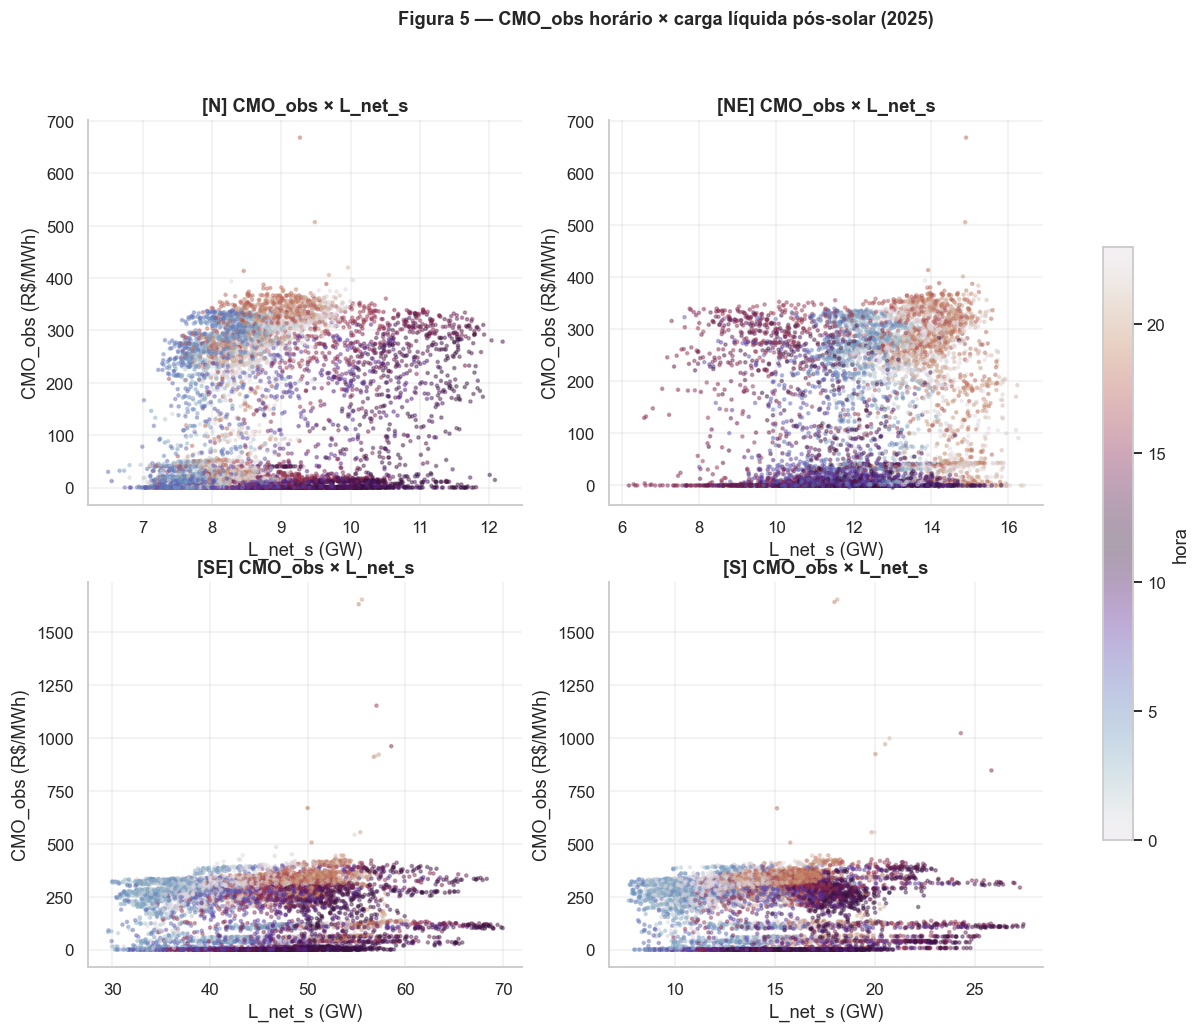

In [10]:
PLD_MIN_2025 = 65.69
PLD_MAX_2025 = 939.96

panel = panel.merge(cmo[["din_instante", "id_subsistema", "cmo_h"]],
                    on=["din_instante", "id_subsistema"], how="left")
panel = panel.rename(columns={"cmo_h": "CMO_obs"})
panel["PLD_obs"] = np.nan
panel["PLD_hat"] = panel["CMO_obs"].clip(lower=PLD_MIN_2025, upper=PLD_MAX_2025)

print("Estatísticas de CMO_obs e PLD_hat por subsistema (R$/MWh):")
print(panel.groupby("id_subsistema")[["CMO_obs", "PLD_hat"]]
      .agg(["mean", "std", lambda x: float(np.nanpercentile(x.dropna(), 95))]).round(1).to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, sub in zip(axes.flat, SUBSYS_ORDER):
    g = panel[panel["id_subsistema"] == sub].dropna(subset=["CMO_obs", "L_net_s"])
    sc = ax.scatter(g["L_net_s"]/1000, g["CMO_obs"], c=g["hora"], cmap="twilight",
                    s=4, alpha=.4, rasterized=True)
    ax.set_title(f"[{sub}] CMO_obs × L_net_s")
    ax.set_xlabel("L_net_s (GW)"); ax.set_ylabel("CMO_obs (R$/MWh)")
    ax.grid(alpha=.3)
fig.colorbar(sc, ax=axes.ravel().tolist(), label="hora", shrink=.7)
fig.suptitle("Figura 5 — CMO_obs horário × carga líquida pós-solar (2025)",
             fontsize=12, fontweight="bold")
fig.savefig(FIGS / "fig05_cmo_vs_Lnet.png", bbox_inches="tight")
plt.show()


## 10. Fator de captura `F_capture` separado por preço

Calculamos:
- `F_capture_CMO`     — usando `CMO_obs`.
- `F_capture_PLD_obs` — usando `PLD_obs` (NaN, indisponível).
- `F_capture_PLD_hat` — usando proxy `PLD_hat`.


Fator de captura por preço de referência:
id_subsistema fonte  F_capture_CMO  F_capture_PLD_hat
            N solar          0.656              0.771
            N  wind          1.356              1.245
           NE solar          0.652              0.774
           NE  wind          1.220              1.146
            S solar          0.929              0.940
            S  wind          1.065              1.052
           SE solar          0.792              0.837
           SE  wind          1.011              0.998


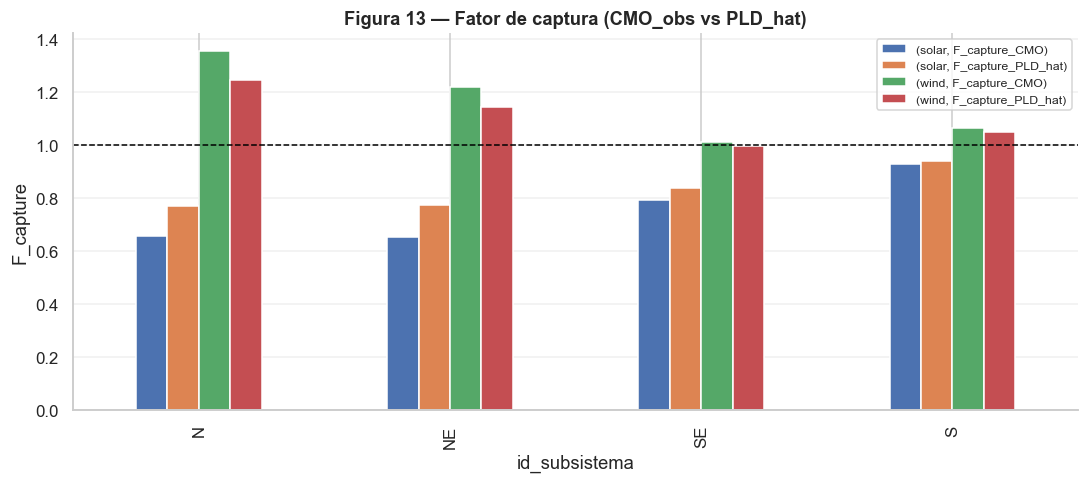

In [11]:
def f_capture(df: pd.DataFrame, sub: str, gen_col: str, price_col: str):
    g = df[(df["id_subsistema"] == sub)].dropna(subset=[price_col, gen_col])
    if len(g) == 0 or g[gen_col].sum() <= 0:
        return np.nan, np.nan, np.nan
    P_avg = float(g[price_col].mean())
    P_cap = float((g[price_col] * g[gen_col]).sum() / g[gen_col].sum())
    return (P_cap / P_avg if P_avg > 0 else np.nan), P_avg, P_cap


records = []
for sub in SUBSYS_ORDER:
    for src, gcol in [("solar", "G_s_total"), ("wind", "G_w_total")]:
        for price_col, tag in [("CMO_obs", "F_capture_CMO"),
                               ("PLD_obs", "F_capture_PLD_obs"),
                               ("PLD_hat", "F_capture_PLD_hat")]:
            Fc, Pavg, Pcap = f_capture(panel, sub, gcol, price_col)
            records.append({"id_subsistema": sub, "fonte": src, "tag": tag,
                            "F_capture": Fc, "P_avg": Pavg, "P_cap": Pcap})
fcap = pd.DataFrame(records)
fcap.to_csv(TABLES / "tab_fator_captura.csv", index=False, float_format="%.4f")

piv = fcap.pivot_table(index=["id_subsistema", "fonte"], columns="tag",
                       values="F_capture").reset_index()
print("Fator de captura por preço de referência:")
print(piv.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
df_plot = (fcap.query("tag in ['F_capture_CMO', 'F_capture_PLD_hat']")
                .pivot_table(index="id_subsistema", columns=["fonte", "tag"], values="F_capture")
                .reindex(SUBSYS_ORDER))
df_plot.plot.bar(ax=ax)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_ylabel("F_capture"); ax.set_title("Figura 13 — Fator de captura (CMO_obs vs PLD_hat)")
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
fig.tight_layout()
fig.savefig(FIGS / "fig13_fator_captura.png", bbox_inches="tight")
plt.show()


## 11. Hidrologia (PROXY)

**Aviso explícito**: por ausência de cota montante, cota jusante e vazão
turbinada por usina, a hidrologia neste notebook é tratada como **proxy** via
afluência observada, geração observada e `vol_util_pct`. Não é uma
modelagem física completa.

A fórmula física, apresentada apenas como referência, é
$P_h = \eta \cdot \rho \cdot g \cdot h_{liq} \cdot q_{turb}$,
onde $\eta$ é a eficiência turbina-gerador, $\rho$ a densidade da água,
$g$ a gravidade, $h_{liq}$ a queda líquida e $q_{turb}$ a vazão turbinada.


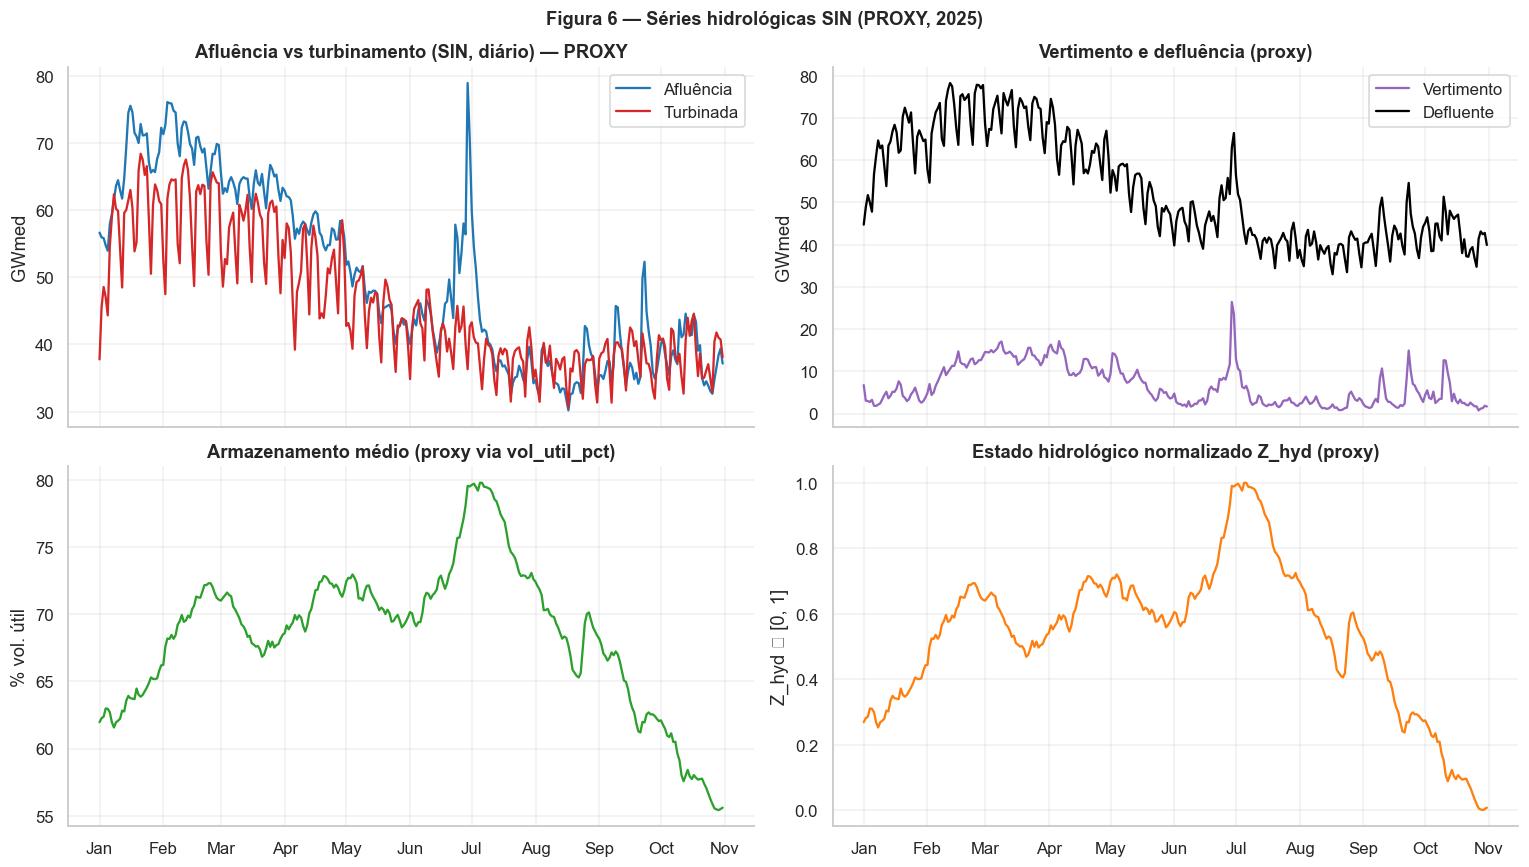

In [12]:
hydro_sin = hydro.copy()
hydro_sin["Storage_MW"] = hydro_sin["A_MW"].cumsum() - hydro_sin["Outflow_MW"].cumsum()
if hydro_sin["vol_util_pct"].notna().any():
    s = hydro_sin["vol_util_pct"]
else:
    s = hydro_sin["Storage_MW"]
hydro_sin["Z_hyd"] = (s - s.min()) / max(s.max() - s.min(), 1e-9)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
ax = axes[0, 0]
ax.plot(hydro_sin["din_instante"], hydro_sin["A_MW"]/1000, label="Afluência", color="#1f77b4")
ax.plot(hydro_sin["din_instante"], hydro_sin["T_MW"]/1000, label="Turbinada", color="#d62728")
ax.set_ylabel("GWmed"); ax.set_title("Afluência vs turbinamento (SIN, diário) — PROXY")
ax.legend(); ax.grid(alpha=.3)

ax = axes[0, 1]
ax.plot(hydro_sin["din_instante"], hydro_sin["Spill_MW"]/1000, label="Vertimento", color="#9467bd")
ax.plot(hydro_sin["din_instante"], hydro_sin["Outflow_MW"]/1000, label="Defluente", color="black")
ax.set_ylabel("GWmed"); ax.set_title("Vertimento e defluência (proxy)")
ax.legend(); ax.grid(alpha=.3)

ax = axes[1, 0]
ax.plot(hydro_sin["din_instante"], hydro_sin["vol_util_pct"], color="#2ca02c")
ax.set_ylabel("% vol. útil"); ax.set_title("Armazenamento médio (proxy via vol_util_pct)")
ax.grid(alpha=.3)

ax = axes[1, 1]
ax.plot(hydro_sin["din_instante"], hydro_sin["Z_hyd"], color="#ff7f0e")
ax.set_ylabel("Z_hyd ∈ [0, 1]"); ax.set_title("Estado hidrológico normalizado Z_hyd (proxy)")
ax.grid(alpha=.3)

for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.suptitle("Figura 6 — Séries hidrológicas SIN (PROXY, 2025)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "fig06_hidrologia_proxy.png", bbox_inches="tight")
plt.show()


## 12. Calibração dos parâmetros do despacho

`CMO_obs = c1 + c2 · g_disp` por mínimos quadrados, onde `g_disp = G_n_total`
(térmica + nuclear, fontes despacháveis). `K_T`, `K_H` via p99,5 da geração
horária agregada. Rampa `ρ` via p99 do `|ΔG_th|`.


In [13]:
g = panel.dropna(subset=["CMO_obs"]).copy()
g["g_disp"] = g["G_n_total"]
y = g["CMO_obs"].values
x = g["g_disp"].values
A = np.column_stack([np.ones_like(x), x])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
c1_lin, c2_lin = float(coef[0]), float(coef[1])
c1 = max(c1_lin, 50.0)
c2 = max(c2_lin, 1e-4)

agg_panel = panel.groupby("din_instante", as_index=False).agg(
    L_global=("L_global", "sum"),
    G_s_total=("G_s_total", "sum"),
    G_w_total=("G_w_total", "sum"),
    G_h_total=("G_h_total", "sum"),
    G_th=("g_th_obs", "sum"),
    G_nuc=("g_nuc_obs", "sum"),
)
K_T_SIN = float(np.nanquantile(agg_panel["G_th"],     0.995))
K_H_SIN = float(np.nanquantile(agg_panel["G_h_total"], 0.995))
dG_th   = agg_panel["G_th"].diff().abs().dropna()
rho_up = rho_dn = float(np.nanquantile(dG_th, 0.99))

PARAMS = {
    "c1_RS_per_MWh":   round(c1, 2),
    "c2_RS_per_MWh2":  round(c2, 6),
    "K_T_SIN_MW":      round(K_T_SIN, 0),
    "K_H_SIN_MW":      round(K_H_SIN, 0),
    "rho_up_MW_per_h": round(rho_up, 0),
    "rho_dn_MW_per_h": round(rho_dn, 0),
    "pi_curt_RS_per_MWh": 30.0,
    "pi_def_RS_per_MWh":  3500.0,
    "VOLL":              3500.0,
    "theta_water_RS_per_MWh": 80.0,
    "V_terminal_RS_per_MWh":  60.0,
}
pd.DataFrame.from_dict(PARAMS, orient="index", columns=["valor"]).to_csv(
    TABLES / "tab_params_dispatch.csv")
print("Parâmetros calibrados do despacho:")
print(pd.DataFrame.from_dict(PARAMS, orient="index", columns=["valor"]).round(3).to_string())


Parâmetros calibrados do despacho:
                            valor
c1_RS_per_MWh             133.130
c2_RS_per_MWh2              0.015
K_T_SIN_MW              13676.000
K_H_SIN_MW              81102.000
rho_up_MW_per_h           683.000
rho_dn_MW_per_h           683.000
pi_curt_RS_per_MWh         30.000
pi_def_RS_per_MWh        3500.000
VOLL                     3500.000
theta_water_RS_per_MWh     80.000
V_terminal_RS_per_MWh      60.000


## 13. Despacho centralizado — hidrelétrica com valor da água, orçamento e valor terminal

Balanço com **carga** (`L_t`, não `D_t`):

$G_{ren,t} + h_t + n_t - L_t - curt_t + def_t = 0,$

custo objetivo:

$\min \sum_t \big[c_1 n_t + \tfrac12 c_2 n_t^2 + \theta_w h_t + \pi_{curt} curt_t + \pi_{def} def_t\big]
- V_{term} (B_h - \sum_t h_t),$

restrições de capacidade `n_t \le K_T`, `h_t \le K_H`, rampa `|n_t - n_{t-1}| \le \rho`,
e **orçamento de energia hidráulica** `\sum_t h_t \le B_h`.

Os componentes (a)–(d) — orçamento, dinâmica simplificada, custo de oportunidade
e valor terminal — corrigem a **degenerescência da hidrelétrica** observada no
despacho original (onde o despacho hidráulico não tinha valor de oportunidade
e era resolvido por arbitrariedade do solver).


In [14]:
def solve_dispatch_day(L: np.ndarray, G_ren: np.ndarray,
                       K_T: float, K_H: float, c1: float, c2: float,
                       rho_up: float, rho_dn: float,
                       theta_water: float = 80.0,
                       hydro_budget: float | None = None,
                       V_terminal: float = 0.0,
                       pi_curt: float = 30.0, pi_def: float = 3500.0) -> dict:
    """Despacho centralizado de 24 h.

    Notação:
      L           — carga horária (load), MW.
      G_ren       — geração renovável exógena horária, MW.
      lambda_model = -bal.dual_value (preço-sombra do balanço, R$/MWh).
                   NÃO é CMO nem PLD.
    """
    T = len(L)
    n = cp.Variable(T, nonneg=True)
    h = cp.Variable(T, nonneg=True)
    curt = cp.Variable(T, nonneg=True)
    defc = cp.Variable(T, nonneg=True)

    cost = (c1 * cp.sum(n) + 0.5 * c2 * cp.sum_squares(n)
            + theta_water * cp.sum(h)
            + pi_curt * cp.sum(curt) + pi_def * cp.sum(defc))

    if hydro_budget is not None and V_terminal != 0.0:
        # Valor terminal: prêmio por economizar água em relação ao orçamento
        cost = cost - V_terminal * (hydro_budget - cp.sum(h))

    bal = (G_ren + h + n) - (L + curt - defc) == 0
    cons = [bal, n <= K_T, h <= K_H,
            n[1:] - n[:-1] <= rho_up,
            n[:-1] - n[1:] <= rho_dn]
    if hydro_budget is not None:
        cons.append(cp.sum(h) <= hydro_budget)

    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)
    lam = -bal.dual_value if bal.dual_value is not None else np.full(T, np.nan)
    return {
        "status": prob.status, "n": np.asarray(n.value), "h": np.asarray(h.value),
        "curt": np.asarray(curt.value), "def": np.asarray(defc.value),
        "lambda_model": np.asarray(lam), "cost": float(prob.value),
    }


def typical_day(panel: pd.DataFrame, sub: str, season: str, td: str) -> pd.DataFrame:
    g = panel.query("id_subsistema == @sub and estacao == @season and tipo_dia_g == @td")
    return g.groupby("hora").agg(
        L_global=("L_global", "mean"),
        G_s_total=("G_s_total", "mean"),
        G_w_total=("G_w_total", "mean"),
        G_h_total=("G_h_total", "mean"),
        G_th=("g_th_obs", "mean"),
        G_nuc=("g_nuc_obs", "mean"),
        CMO_obs=("CMO_obs", "mean"),
    ).reindex(range(24))


rows = []
results_disp = {}
for sub in SUBSYS_ORDER:
    for est in SEASON_ORDER:
        for td in ["util", "fim_semana_feriado"]:
            prof = typical_day(panel, sub, est, td)
            if prof["L_global"].isna().all():
                continue
            prof = prof.ffill().bfill().fillna(0.0)
            L     = prof["L_global"].values
            G_ren = (prof["G_s_total"] + prof["G_w_total"]).values
            K_T_l = float(K_eff.loc[sub, "K_n_eff_p99"])
            K_H_l = float(K_eff.loc[sub, "K_h_eff_p99"])
            B_h   = float(prof["G_h_total"].sum() * 0.95)   # orçamento diário ≈ 95% obs.
            d_th  = panel.loc[panel["id_subsistema"] == sub, "g_th_obs"].diff().abs()
            rho_l = float(np.nanquantile(d_th.dropna(), 0.99))
            res = solve_dispatch_day(
                L, G_ren, K_T_l, K_H_l,
                c1=PARAMS["c1_RS_per_MWh"], c2=PARAMS["c2_RS_per_MWh2"],
                rho_up=rho_l, rho_dn=rho_l,
                theta_water=PARAMS["theta_water_RS_per_MWh"],
                hydro_budget=B_h,
                V_terminal=PARAMS["V_terminal_RS_per_MWh"],
                pi_curt=PARAMS["pi_curt_RS_per_MWh"],
                pi_def=PARAMS["pi_def_RS_per_MWh"],
            )
            results_disp[(sub, est, td)] = res
            rows.append({
                "subsistema": sub, "estacao": est, "tipo_dia": td,
                "status": res["status"], "cost": res["cost"],
                "G_th_total": float(res["n"].sum()),
                "G_h_total":  float(res["h"].sum()),
                "curt_total": float(res["curt"].sum()),
                "def_total":  float(res["def"].sum()),
                "lambda_model_mean": float(np.nanmean(res["lambda_model"])),
                "CMO_obs_mean": float(np.nanmean(prof["CMO_obs"])),
            })
disp_summary = pd.DataFrame(rows)
disp_summary.to_csv(TABLES / "tab_despacho_centralizado.csv", index=False, float_format="%.2f")
print("Resumo do despacho centralizado por (subsistema, estação, tipo_dia):")
print(disp_summary.round(1).to_string(index=False))


Resumo do despacho centralizado por (subsistema, estação, tipo_dia):
subsistema   estacao           tipo_dia  status         cost  G_th_total  G_h_total  curt_total  def_total  lambda_model_mean  CMO_obs_mean
         N     verao               util optimal    9863421.0     10742.8   184728.0         0.0        0.0              140.0          19.4
         N     verao fim_semana_feriado optimal   12126762.5     10742.8   170755.7         0.0        0.0              140.0          13.0
         N    outono               util optimal   10754122.9     10742.8   196781.0         0.0        0.0              140.0          68.8
         N    outono fim_semana_feriado optimal   11749392.4     10742.8   185979.7         0.0        0.0              140.0          38.0
         N   inverno               util optimal   92374871.8     82696.4   109462.4         0.0    20120.5             3500.0         250.4
         N   inverno fim_semana_feriado optimal   91390697.7     82696.4    97697.2        

### Figura 7 — Despacho central de dia típico (SE, verão, dia útil)

Demonstra que `lambda_model` (preço-sombra) é coerente em ordem de grandeza
com `CMO_obs` mas NÃO é o CMO em si.


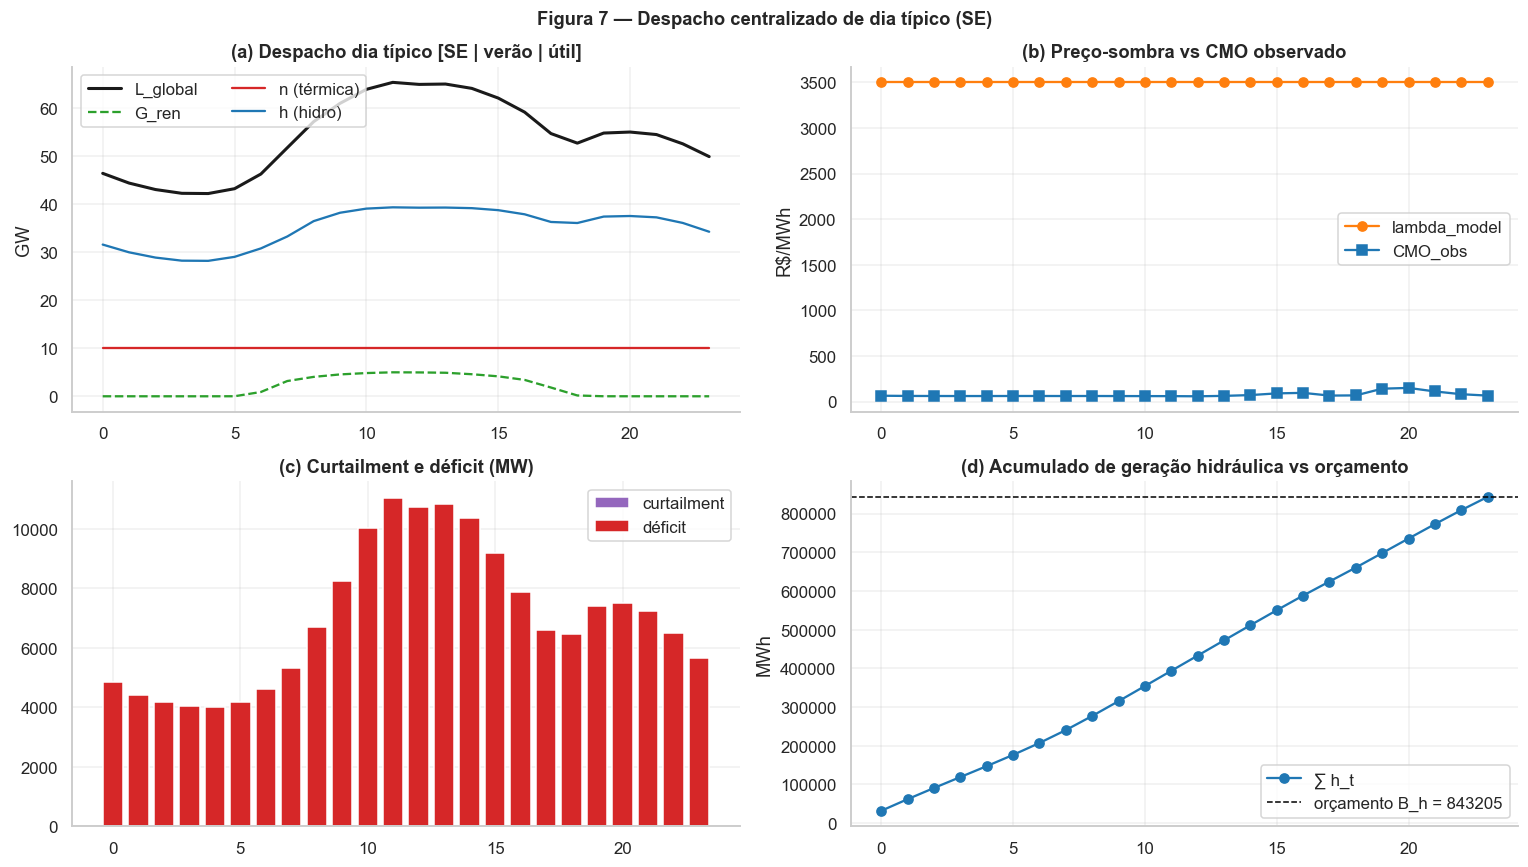

In [15]:
key = ("SE", "verao", "util")
if key in results_disp:
    r = results_disp[key]
    prof = typical_day(panel, *key).ffill().bfill().fillna(0.0)
    hours = np.arange(24)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax = axes[0, 0]
    ax.plot(hours, prof["L_global"]/1000, "k-", lw=2, label="L_global")
    ax.plot(hours, (prof["G_s_total"]+prof["G_w_total"])/1000, "--", color="#2ca02c", label="G_ren")
    ax.plot(hours, r["n"]/1000, color="#d62728", label="n (térmica)")
    ax.plot(hours, r["h"]/1000, color="#1f77b4", label="h (hidro)")
    ax.set_title("(a) Despacho dia típico [SE | verão | útil]"); ax.set_ylabel("GW")
    ax.legend(ncols=2); ax.grid(alpha=.3)

    ax = axes[0, 1]
    ax.plot(hours, r["lambda_model"], "o-", color="#ff7f0e", label="lambda_model")
    ax.plot(hours, prof["CMO_obs"],   "s-", color="#1f77b4", label="CMO_obs")
    ax.set_title("(b) Preço-sombra vs CMO observado"); ax.set_ylabel("R$/MWh")
    ax.legend(); ax.grid(alpha=.3)

    ax = axes[1, 0]
    ax.bar(hours, r["curt"], color="#9467bd", label="curtailment")
    ax.bar(hours, r["def"],  color="#d62728", label="déficit")
    ax.set_title("(c) Curtailment e déficit (MW)"); ax.legend(); ax.grid(alpha=.3)

    ax = axes[1, 1]
    cum = np.cumsum(r["h"])
    ax.plot(hours, cum, "-o", color="#1f77b4", label="∑ h_t")
    B_h = float(prof["G_h_total"].sum() * 0.95)
    ax.axhline(B_h, color="black", ls="--", lw=1, label=f"orçamento B_h = {B_h:.0f}")
    ax.set_title("(d) Acumulado de geração hidráulica vs orçamento"); ax.set_ylabel("MWh")
    ax.legend(); ax.grid(alpha=.3)

    fig.suptitle("Figura 7 — Despacho centralizado de dia típico (SE)", fontsize=12, fontweight="bold")
    fig.tight_layout()
    fig.savefig(FIGS / "fig07_despacho_dia_tipico_SE.png", bbox_inches="tight")
    plt.show()


## 14. Modelo situacional finito

Dois produtores **solares** (incumbente + entrante), uma **térmica** e uma
**hidrelétrica**; a **eólica** entra como exógena. Calibração para o SIN
agregado, 8 dias típicos (4 estações × 2 tipos de dia, 192 horas).

Para cada cenário (`kappa = K_2 / K_1`), reportamos:
custo, térmica, hidráulica, curtailment, déficit, `lambda_model`,
receita capturada `R_cap` e fator de captura `F_capture` (baseados em `lambda_model`).


In [16]:
# Templates SIN — 8 dias típicos
agg = panel.groupby("din_instante", as_index=False).agg(
    L_global=("L_global", "sum"),
    G_s_total=("G_s_total", "sum"),
    G_w_total=("G_w_total", "sum"),
    G_h_total=("G_h_total", "sum"),
    G_th=("g_th_obs", "sum"),
    G_nuc=("g_nuc_obs", "sum"),
)
agg = add_calendar(agg)
typ_sin = (agg.groupby(["estacao", "tipo_dia_g", "hora"], observed=False)
              .agg(L=("L_global", "mean"),
                   Gs=("G_s_total", "mean"),
                   Gw=("G_w_total", "mean"),
                   Gh=("G_h_total", "mean"),
                   Gth=("G_th", "mean"),
                   Gnuc=("G_nuc", "mean"))
              .reindex(pd.MultiIndex.from_product(
                  [SEASON_ORDER, ["util", "fim_semana_feriado"], range(24)],
                  names=["estacao", "tipo_dia_g", "hora"]))
              .ffill().bfill()
              .reset_index())

# Concatena 8 blocos de 24h em sequência fixa
blocks = []
for est in SEASON_ORDER:
    for td in ["util", "fim_semana_feriado"]:
        d = typ_sin.query("estacao == @est and tipo_dia_g == @td").sort_values("hora").copy()
        d["bloco"] = f"{est}-{td}"
        blocks.append(d)
template = pd.concat(blocks, ignore_index=True)
T_HOURS = len(template)   # = 192

# Calibração SIN
y_sin = panel.dropna(subset=["CMO_obs"])["CMO_obs"].values
x_sin = panel.dropna(subset=["CMO_obs"])["G_n_total"].values
A = np.column_stack([np.ones_like(x_sin), x_sin])
coef_sin, *_ = np.linalg.lstsq(A, y_sin, rcond=None)
c1_sit, c2_sit = max(float(coef_sin[0]), 50.0), max(float(coef_sin[1]), 1e-6)

K_T_SIT = float(np.nanquantile(agg["G_th"], 0.995))
K_H_SIT = float(np.nanquantile(agg["G_h_total"], 0.995))
K_S_SIT = float(K_eff.loc[:, "K_s_eff_p99"].sum())
K_W_SIT = float(K_eff.loc[:, "K_w_eff_p99"].sum())

a_s_t = (template["Gs"].values / max(K_S_SIT, 1e-6)).clip(0.0, 1.5)
a_w_t = (template["Gw"].values / max(K_W_SIT, 1e-6)).clip(0.0, 1.5)
Gw_exog = a_w_t * K_W_SIT
L_t = template["L"].values

# Orçamento hidráulico diário ≈ 95% obs.; aqui agregamos por dia
B_h_daily = float(template.groupby("bloco")["Gh"].sum().mean() * 0.95)

print(f"T_HOURS = {T_HOURS} | c1 = {c1_sit:.1f} | c2 = {c2_sit:.6f}")
print(f"K_T_SIT = {K_T_SIT/1000:.1f} GW | K_H_SIT = {K_H_SIT/1000:.1f} GW | "
      f"K_S_SIT = {K_S_SIT/1000:.1f} GW | K_W_SIT = {K_W_SIT/1000:.1f} GW")


T_HOURS = 192 | c1 = 133.1 | c2 = 0.015348
K_T_SIT = 13.7 GW | K_H_SIT = 81.1 GW | K_S_SIT = 13.5 GW | K_W_SIT = 24.1 GW


In [17]:
def solve_situational(K1: float, kappa: float = 0.0,
                      hyd_scale: float = 1.0) -> dict:
    """Modelo situacional finito: 2 solares + térmica + hidro; eólica exógena.

    Retorna g1, g2 (geração solar de cada agente), n, h, curt, def, lambda_model,
    R_cap_1, R_cap_2, F_capture_1, F_capture_2, cost.
    """
    T = T_HOURS
    K2 = kappa * K1
    g1 = cp.Variable(T, nonneg=True)
    g2 = cp.Variable(T, nonneg=True)
    n  = cp.Variable(T, nonneg=True)
    h  = cp.Variable(T, nonneg=True)
    curt = cp.Variable(T, nonneg=True)
    defc = cp.Variable(T, nonneg=True)

    cost = (c1_sit * cp.sum(n) + 0.5 * c2_sit * cp.sum_squares(n)
            + PARAMS["theta_water_RS_per_MWh"] * cp.sum(h)
            + PARAMS["pi_curt_RS_per_MWh"] * cp.sum(curt)
            + PARAMS["pi_def_RS_per_MWh"] * cp.sum(defc))

    # Balanço com L_t (CARGA)
    bal = (g1 + g2 + Gw_exog + h + n) - (L_t + curt - defc) == 0

    cons = [bal, n <= K_T_SIT, h <= K_H_SIT * hyd_scale,
            g1 <= a_s_t * K1, g2 <= a_s_t * K2]
    # Orçamento hidráulico diário: 8 blocos de 24h
    for k in range(8):
        cons.append(cp.sum(h[k*24:(k+1)*24]) <= B_h_daily * hyd_scale)

    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)
    lam = -bal.dual_value if bal.dual_value is not None else np.full(T, np.nan)

    G1 = np.asarray(g1.value); G2 = np.asarray(g2.value)
    R1 = float((lam * G1).sum())
    R2 = float((lam * G2).sum())
    P_avg = float(np.nanmean(lam))
    Fc1 = (R1 / max(G1.sum(), 1e-9)) / max(P_avg, 1e-9)
    Fc2 = (R2 / max(G2.sum(), 1e-9)) / max(P_avg, 1e-9)
    return {
        "status": prob.status, "cost": float(prob.value),
        "g1": G1, "g2": G2, "n": np.asarray(n.value), "h": np.asarray(h.value),
        "curt": np.asarray(curt.value), "def": np.asarray(defc.value),
        "lambda_model": np.asarray(lam),
        "K1": K1, "K2": K2,
        "R_cap_1": R1, "R_cap_2": R2,
        "F_capture_1": Fc1, "F_capture_2": Fc2,
    }


KAPPAS = [0.0, 0.25, 0.5, 1.0, 2.0]
results_sit = {k: solve_situational(K_S_SIT, k) for k in KAPPAS}

rows = []
for k, r in results_sit.items():
    rows.append({
        "kappa": k,
        "cost": r["cost"],
        "G_th_total": float(r["n"].sum()),
        "G_h_total":  float(r["h"].sum()),
        "curt_total": float(r["curt"].sum()),
        "def_total":  float(r["def"].sum()),
        "lambda_model_mean": float(np.nanmean(r["lambda_model"])),
        "R_cap_1": r["R_cap_1"], "R_cap_2": r["R_cap_2"],
        "F_capture_1": r["F_capture_1"], "F_capture_2": r["F_capture_2"],
    })
sit_summary = pd.DataFrame(rows)
sit_summary.to_csv(TABLES / "tab_situacional_kappa.csv", index=False, float_format="%.4f")
print("Modelo situacional — sensibilidade ao tamanho do entrante (κ = K_2/K_1):")
print(sit_summary.round(3).to_string(index=False))


Modelo situacional — sensibilidade ao tamanho do entrante (κ = K_2/K_1):
 kappa         cost  G_th_total   G_h_total  curt_total   def_total  lambda_model_mean      R_cap_1      R_cap_2  F_capture_1  F_capture_2
  0.00 7.484624e+09 2479899.138 8292628.162       0.003 1782690.086           2699.099 1.813862e+09 0.000000e+00        1.009        0.018
  0.25 7.031429e+09 2439422.493 8292628.162       0.000 1656651.741           2695.863 1.811699e+09 4.529247e+08        1.009        1.009
  0.50 6.597718e+09 2392949.110 8292628.162       0.000 1536610.139           2297.526 1.625042e+09 8.125208e+08        1.062        1.062
  1.00 5.786551e+09 2282811.231 8292628.162       0.000 1313718.050           2288.722 1.619626e+09 1.619626e+09        1.062        1.062
  2.00 4.206964e+09 2051580.499 8292628.162       0.000  878888.846           1875.617 1.331635e+09 2.663270e+09        1.066        1.066


### Figura 9 — Sensibilidade do modelo situacional a κ = K₂/K₁

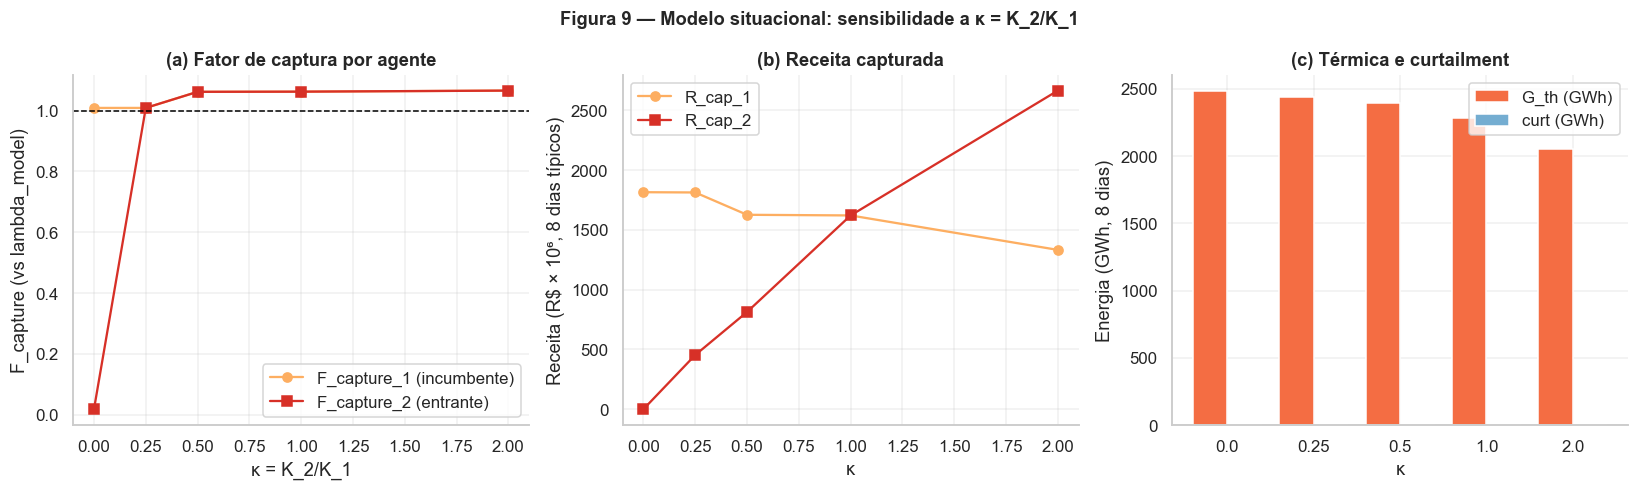

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.plot(sit_summary["kappa"], sit_summary["F_capture_1"], "o-", color="#fdae61", label="F_capture_1 (incumbente)")
ax.plot(sit_summary["kappa"], sit_summary["F_capture_2"], "s-", color="#d73027", label="F_capture_2 (entrante)")
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_xlabel("κ = K_2/K_1"); ax.set_ylabel("F_capture (vs lambda_model)")
ax.set_title("(a) Fator de captura por agente"); ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
ax.plot(sit_summary["kappa"], sit_summary["R_cap_1"]/1e6, "o-", color="#fdae61", label="R_cap_1")
ax.plot(sit_summary["kappa"], sit_summary["R_cap_2"]/1e6, "s-", color="#d73027", label="R_cap_2")
ax.set_xlabel("κ"); ax.set_ylabel("Receita (R$ × 10⁶, 8 dias típicos)")
ax.set_title("(b) Receita capturada"); ax.legend(); ax.grid(alpha=.3)

ax = axes[2]
ax.bar(np.arange(len(KAPPAS)) - 0.2, sit_summary["G_th_total"]/1e3, width=0.4, color="#f46d43", label="G_th (GWh)")
ax.bar(np.arange(len(KAPPAS)) + 0.2, sit_summary["curt_total"]/1e3, width=0.4, color="#74add1", label="curt (GWh)")
ax.set_xticks(np.arange(len(KAPPAS)))
ax.set_xticklabels([f"{k}" for k in KAPPAS])
ax.set_xlabel("κ"); ax.set_ylabel("Energia (GWh, 8 dias)")
ax.set_title("(c) Térmica e curtailment"); ax.legend(); ax.grid(alpha=.3)

fig.suptitle("Figura 9 — Modelo situacional: sensibilidade a κ = K_2/K_1",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "fig09_situacional_sensibilidade.png", bbox_inches="tight")
plt.show()


## 15. Valor marginal da água — sensibilidade hidrológica

Variamos `hyd_scale ∈ {0.7, 1.0, 1.3}` (cenários seca, base, úmida).
Reportamos `theta_water` efetivo via `lambda_model` médio e os custos
operacionais resultantes.


Sensibilidade hidrológica (3 cenários):
     cenario  cost (R$ x10^6)  G_th_total (GWh)  G_h_total (GWh)  curt (GWh)  def (MWh)  lambda_model_mean (R$/MWh)
 seca (-30%)         14360.17           2625.73          5804.84         0.0 3791615.34                     3500.00
        base          6597.72           2392.95          8292.63         0.0 1536610.14                     2297.53
umida (+30%)          2202.17           1332.31         10588.12         0.0  301760.57                     1015.59


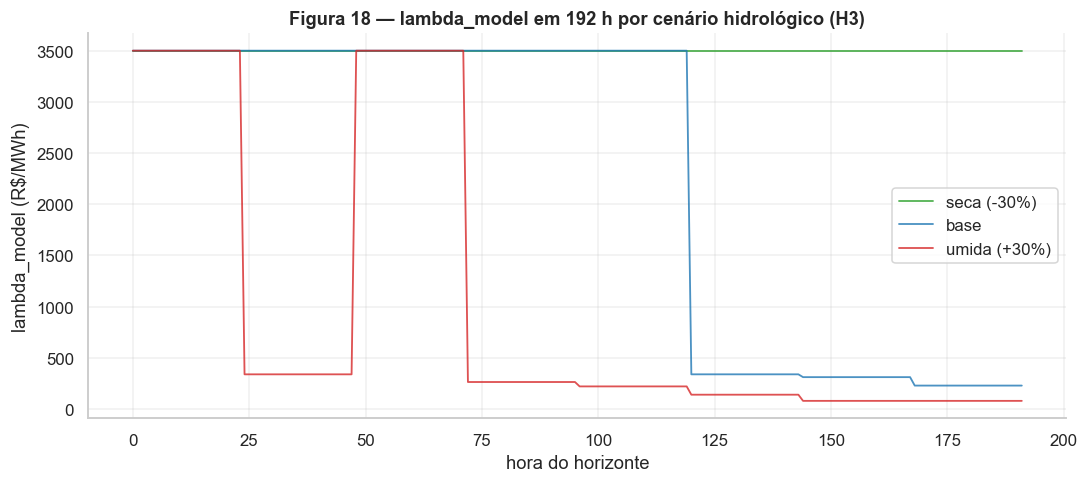

In [19]:
SCEN_H = {"seca (-30%)": 0.7, "base": 1.0, "umida (+30%)": 1.3}
hidro_res = {name: solve_situational(K_S_SIT, kappa=0.5, hyd_scale=sc)
             for name, sc in SCEN_H.items()}

rows = []
for name, r in hidro_res.items():
    rows.append({
        "cenario": name,
        "cost (R$ x10^6)":          r["cost"] / 1e6,
        "G_th_total (GWh)":          r["n"].sum() / 1e3,
        "G_h_total (GWh)":           r["h"].sum() / 1e3,
        "curt (GWh)":                r["curt"].sum() / 1e3,
        "def (MWh)":                 r["def"].sum(),
        "lambda_model_mean (R$/MWh)": float(np.nanmean(r["lambda_model"])),
    })
val_agua = pd.DataFrame(rows)
val_agua.to_csv(TABLES / "tab_valor_agua_cenarios.csv", index=False, float_format="%.3f")
print("Sensibilidade hidrológica (3 cenários):")
print(val_agua.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
for (name, r), color in zip(hidro_res.items(), ["#2ca02c", "#1f77b4", "#d62728"]):
    ax.plot(r["lambda_model"], lw=1.2, alpha=.8, color=color, label=name)
ax.set_title("Figura 18 — lambda_model em 192 h por cenário hidrológico (H3)")
ax.set_xlabel("hora do horizonte"); ax.set_ylabel("lambda_model (R$/MWh)")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIGS / "fig18_valor_agua.png", bbox_inches="tight")
plt.show()


## 16. Modelo **locacional inspirado em MFG** (não MFG completo)

Este bloco resolve um *clearing locacional* (4 subsistemas, dia típico de
24 h) acoplado a uma **iteração de preços** (ponto fixo em `lambda_model`).

**Por que não MFG completo?** Não modelamos explicitamente:
- distribuição populacional `m^τ_{ℓ, t}` dos agentes,
- estado individual e política ótima `π^τ_{ℓ, t}`,
- equação forward para a evolução de `m`.

A iteração executa: dado `lambda^k`, resolve clearing → atualiza
`lambda^{k+1}` via mistura `(1-ω) lambda^k + ω lambda^{model}`. Isso é
um **proxy de ponto fixo**, não um equilíbrio MFG formal.

Separamos explicitamente:
1. **Clearing locacional** (LP/QP de 24h sobre 4 subsistemas + 4 corredores).
2. **Iteração de preços** (relaxação amortecida).
3. **Critério de equilíbrio** (erro máximo `||lambda_{k+1} - lambda_k||_∞ < ε`).


In [20]:
# Perfis horários típicos por subsistema (24h)
typ_loc = (panel.groupby(["id_subsistema", "hora"])
                .agg(L=("L_global", "mean"),
                     Gs=("G_s_total", "mean"),
                     Gw=("G_w_total", "mean"),
                     Gh=("G_h_total", "mean"),
                     Gth=("g_th_obs", "mean"),
                     CMO_obs=("CMO_obs", "mean"))
                .reset_index())

# Intercâmbio: limites F_max por corredor
intc_raw = pd.read_csv(paths.interc_interno_path, sep=";", parse_dates=["din_instante"])
intc_raw = intc_raw[intc_raw["din_instante"].between(DATE_MIN, DATE_MAX)]
intc_raw["o"] = intc_raw["nom_subsistema_origem"].astype(str).map(canonical_subsys)
intc_raw["d"] = intc_raw["nom_subsistema_destino"].astype(str).map(canonical_subsys)
flow_lim = (intc_raw.groupby(["o", "d"])["val_intercambiomwmed"]
            .apply(lambda x: float(np.nanquantile(x.abs(), 0.99))).reset_index()
            .rename(columns={"val_intercambiomwmed": "F_max"}))

ALL_LINKS = [("N", "NE"), ("N", "SE"), ("NE", "SE"), ("SE", "S")]
F_MAX = {(o, d): float(flow_lim.query("o == @o and d == @d")["F_max"].iloc[0])
        if len(flow_lim.query("o == @o and d == @d")) else 0.0
        for (o, d) in ALL_LINKS}
print("Limites F_max (MW) por corredor:", {k: f"{v:.0f}" for k, v in F_MAX.items()})

# Parâmetros locacionais por subsistema
L_lt    = {s: typ_loc.query("id_subsistema == @s").sort_values("hora")["L"].values
           for s in SUBSYS_ORDER}
Gren_lt = {s: (typ_loc.query("id_subsistema == @s").sort_values("hora")["Gs"].values
              + typ_loc.query("id_subsistema == @s").sort_values("hora")["Gw"].values)
           for s in SUBSYS_ORDER}
Havail_lt = {s: typ_loc.query("id_subsistema == @s").sort_values("hora")["Gh"].values
             for s in SUBSYS_ORDER}
K_T_loc = {s: float(K_eff.loc[s, "K_n_eff_p99"]) for s in SUBSYS_ORDER}
K_H_loc = {s: float(K_eff.loc[s, "K_h_eff_p99"]) for s in SUBSYS_ORDER}

# Calibração local de c1/c2 por subsistema
c1_loc, c2_loc = {}, {}
for s in SUBSYS_ORDER:
    g = panel[(panel["id_subsistema"] == s)].dropna(subset=["CMO_obs"])
    if len(g) < 30:
        c1_loc[s], c2_loc[s] = c1_sit, c2_sit
        continue
    y = g["CMO_obs"].values
    x = g["G_n_total"].values
    A = np.column_stack([np.ones_like(x), x])
    cf, *_ = np.linalg.lstsq(A, y, rcond=None)
    c1_loc[s] = max(float(cf[0]), 50.0)
    c2_loc[s] = max(float(cf[1]), 5e-3)


Limites F_max (MW) por corredor: {('N', 'NE'): '5651', ('N', 'SE'): '9580', ('NE', 'SE'): '7629', ('SE', 'S'): '8576'}


In [21]:
def clearing_locacional(L_lt, Gren_lt, K_T_l, K_H_l, c1_l, c2_l, H_avail_lt,
                       theta_water: float = 80.0,
                       pi_curt: float = 30.0, pi_def: float = 3500.0) -> dict:
    """Clearing locacional 24h (4 subsistemas + 4 corredores).

    NOTA: o balanço usa **carga locacional** L_{ℓ,t}. Retorna `lambda_model[ℓ]`
    (preço-sombra por subsistema), explicitamente não denominado de CMO/PLD.
    """
    T = 24
    locs = SUBSYS_ORDER
    n = {l: cp.Variable(T, nonneg=True) for l in locs}
    h = {l: cp.Variable(T, nonneg=True) for l in locs}
    curt = {l: cp.Variable(T, nonneg=True) for l in locs}
    defc = {l: cp.Variable(T, nonneg=True) for l in locs}
    F = {(o, d): cp.Variable(T) for (o, d) in ALL_LINKS}

    cost = 0
    for l in locs:
        cost += (c1_l[l] * cp.sum(n[l]) + 0.5 * c2_l[l] * cp.sum_squares(n[l])
                 + theta_water * cp.sum(h[l])
                 + pi_def * cp.sum(defc[l]) + pi_curt * cp.sum(curt[l]))

    bal = {}
    cons = []
    for l in locs:
        inflow  = sum(F[(o, d)] for (o, d) in ALL_LINKS if d == l)
        outflow = sum(F[(o, d)] for (o, d) in ALL_LINKS if o == l)
        bal[l] = (Gren_lt[l] + h[l] + n[l] + inflow - outflow) == (L_lt[l] + curt[l] - defc[l])
        cons.append(bal[l])
        cons.append(n[l] <= K_T_l[l])
        cons.append(h[l] <= H_avail_lt[l])
        cons.append(cp.sum(h[l]) <= H_avail_lt[l].sum() * 0.95)
    for (o, d) in ALL_LINKS:
        cons.append(F[(o, d)] <=  F_MAX[(o, d)])
        cons.append(F[(o, d)] >= -F_MAX[(o, d)])

    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)

    lam_l = {l: -bal[l].dual_value if bal[l].dual_value is not None else np.full(T, np.nan)
             for l in locs}
    return {
        "status": prob.status, "cost": float(prob.value),
        "n":    {l: n[l].value    for l in locs},
        "h":    {l: h[l].value    for l in locs},
        "curt": {l: curt[l].value for l in locs},
        "def":  {l: defc[l].value for l in locs},
        "F":    {k: F[k].value    for k in F},
        "lambda_model": lam_l,
    }


# Etapa 1: clearing single-shot
res_clearing = clearing_locacional(L_lt, Gren_lt, K_T_loc, K_H_loc,
                                   c1_loc, c2_loc, Havail_lt,
                                   theta_water=PARAMS["theta_water_RS_per_MWh"])
print(f"clearing status = {res_clearing['status']} | cost = {res_clearing['cost']:.1f} R$")


clearing status = optimal | cost = 882890263.9 R$


### 16.1 Iteração de preços (proxy de ponto fixo)

Iteração de preços convergiu em 15 passos | err = 0.0093


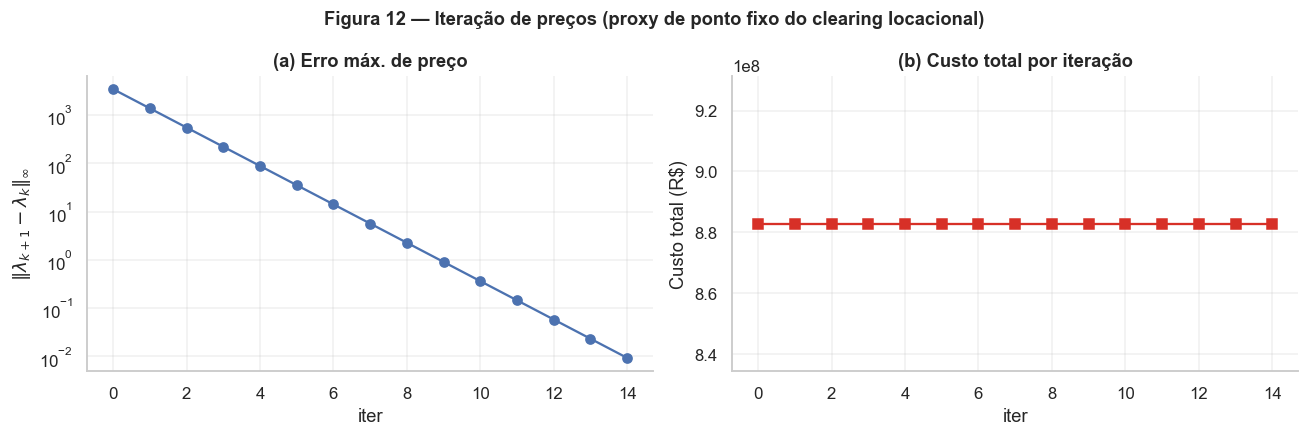

In [22]:
N_ITER = 30
OMEGA  = 0.6
EPS    = 1e-2

lam_obs = (panel.groupby(["id_subsistema", "hora"])["CMO_obs"]
                .mean().unstack().reindex(SUBSYS_ORDER))
lam = {l: lam_obs.loc[l].values for l in SUBSYS_ORDER}
hist = {"err": [], "cost": []}

for k in range(N_ITER):
    res = clearing_locacional(L_lt, Gren_lt, K_T_loc, K_H_loc,
                              c1_loc, c2_loc, Havail_lt,
                              theta_water=PARAMS["theta_water_RS_per_MWh"])
    lam_new = res["lambda_model"]
    err = max(np.nanmax(np.abs(lam_new[l] - lam[l])) for l in SUBSYS_ORDER)
    hist["err"].append(err); hist["cost"].append(res["cost"])
    for l in SUBSYS_ORDER:
        lam[l] = (1 - OMEGA) * lam[l] + OMEGA * lam_new[l]
    if err < EPS:
        print(f"Iteração de preços convergiu em {k+1} passos | err = {err:.4f}")
        break

res_loc = res
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["err"], "o-")
axes[0].set_yscale("log"); axes[0].set_xlabel("iter")
axes[0].set_ylabel(r"$\|\lambda_{k+1} - \lambda_k\|_\infty$")
axes[0].set_title("(a) Erro máx. de preço"); axes[0].grid(alpha=.3)
axes[1].plot(hist["cost"], "s-", color="#d73027")
axes[1].set_xlabel("iter"); axes[1].set_ylabel("Custo total (R$)")
axes[1].set_title("(b) Custo total por iteração"); axes[1].grid(alpha=.3)
fig.suptitle("Figura 12 — Iteração de preços (proxy de ponto fixo do clearing locacional)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "fig12_iteracao_precos.png", bbox_inches="tight")
plt.show()


### 16.2 Equilíbrio locacional (Figura 19)

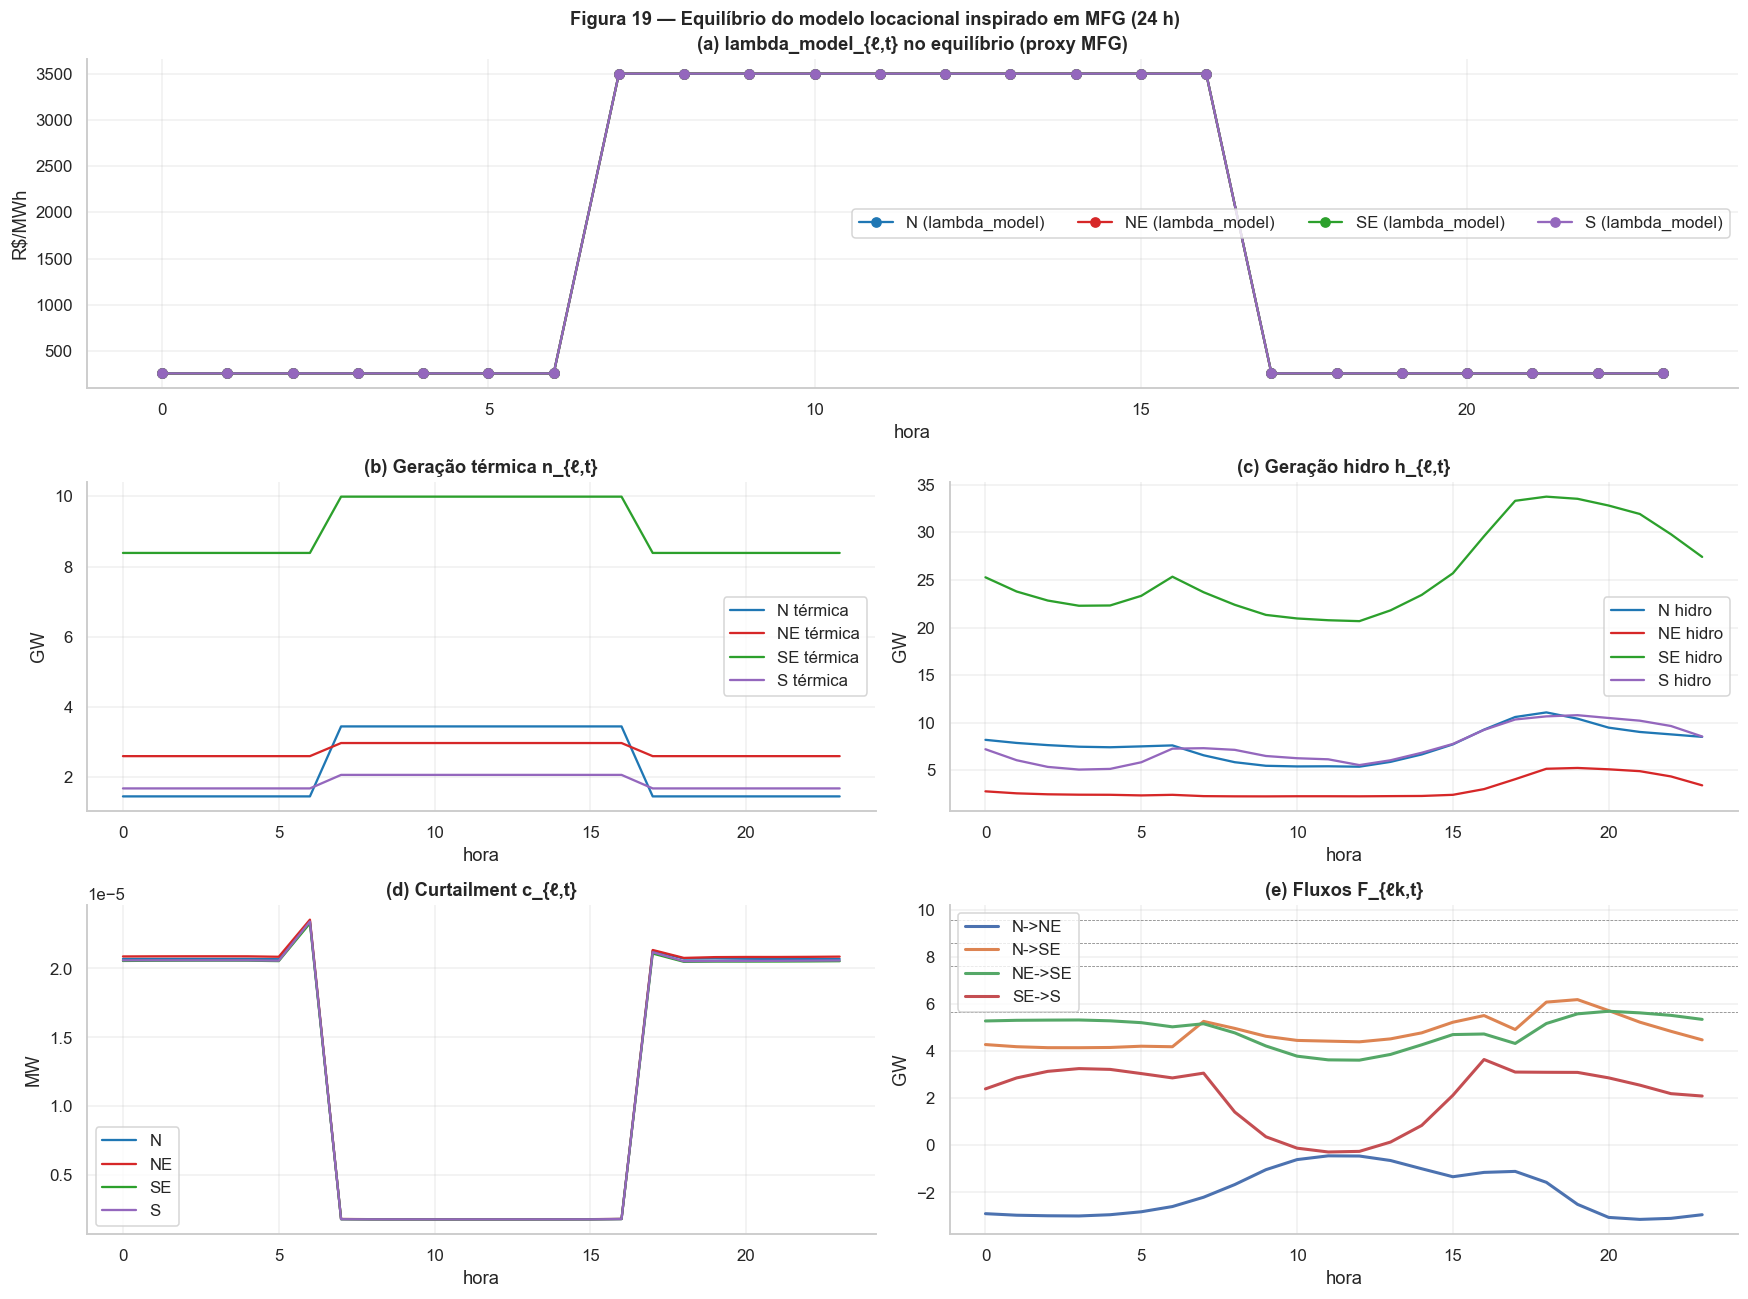

In [23]:
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 2)

ax = fig.add_subplot(gs[0, :])
for l in SUBSYS_ORDER:
    ax.plot(np.arange(24), res_loc["lambda_model"][l], "o-",
            color=SUB_COLOR[l], label=f"{l} (lambda_model)")
ax.set_title("(a) lambda_model_{ℓ,t} no equilíbrio (proxy MFG)")
ax.set_xlabel("hora"); ax.set_ylabel("R$/MWh")
ax.legend(ncols=4); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[1, 0])
for l in SUBSYS_ORDER:
    ax.plot(np.arange(24), res_loc["n"][l]/1000, "-", color=SUB_COLOR[l], label=f"{l} térmica")
ax.set_title("(b) Geração térmica n_{ℓ,t}")
ax.set_xlabel("hora"); ax.set_ylabel("GW"); ax.legend(); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[1, 1])
for l in SUBSYS_ORDER:
    ax.plot(np.arange(24), res_loc["h"][l]/1000, "-", color=SUB_COLOR[l], label=f"{l} hidro")
ax.set_title("(c) Geração hidro h_{ℓ,t}")
ax.set_xlabel("hora"); ax.set_ylabel("GW"); ax.legend(); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[2, 0])
for l in SUBSYS_ORDER:
    ax.plot(np.arange(24), res_loc["curt"][l], "-", color=SUB_COLOR[l], label=f"{l}")
ax.set_title("(d) Curtailment c_{ℓ,t}"); ax.set_xlabel("hora"); ax.set_ylabel("MW")
ax.legend(); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[2, 1])
for (o, d) in ALL_LINKS:
    ax.plot(np.arange(24), res_loc["F"][(o, d)]/1000, "-", lw=2, label=f"{o}->{d}")
    ax.axhline(F_MAX[(o, d)]/1000, color="gray", ls="--", lw=0.5)
ax.set_title("(e) Fluxos F_{ℓk,t}")
ax.set_xlabel("hora"); ax.set_ylabel("GW"); ax.legend(); ax.grid(alpha=.3)

fig.suptitle("Figura 19 — Equilíbrio do modelo locacional inspirado em MFG (24 h)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "fig19_locacional_mfg.png", bbox_inches="tight")
plt.show()

# Salva tabela de equilíbrio
loc_eq_rows = []
for l in SUBSYS_ORDER:
    loc_eq_rows.append({
        "subsistema": l,
        "G_th": float(res_loc["n"][l].sum()),
        "G_h":  float(res_loc["h"][l].sum()),
        "curt": float(res_loc["curt"][l].sum()),
        "def":  float(res_loc["def"][l].sum()),
        "lambda_model_mean": float(np.nanmean(res_loc["lambda_model"][l])),
        "CMO_obs_mean": float(np.nanmean(lam_obs.loc[l])),
    })
pd.DataFrame(loc_eq_rows).to_csv(TABLES / "tab_locacional_equilibrio.csv",
                                 index=False, float_format="%.2f")


## 17. Investimento: capacidade fixa **vs** livre entrada

Diferenciamos:
1. **Alocação com capacidade total fixa** `K_TOT` entre subsistemas
   (problema *welfare* de localização).
2. **Livre entrada** privada — busca a capacidade `K^priv` que satisfaz
   `margem_anual(K^priv) ≥ 0` para o agente.

Se todas as margens forem negativas no operating point observado, **não**
interpretamos isso como equilíbrio de entrada positiva: declaramos
explicitamente que `K^priv = 0` é o equilíbrio (ou usamos `K^priv = K_obs`
apenas como ponto de operação inercial, fora de equilíbrio).


In [24]:
HOURS_YEAR = 8760
WACC = 0.08
VIDA = 25
FATOR_ANUAL = WACC * (1 + WACC)**VIDA / ((1 + WACC)**VIDA - 1)

# Custos regionais (milhões R$/MW); fator anualizado * vida útil
capex_reg = {"N": 4.2, "NE": 3.6, "SE": 3.8, "S": 4.0}
conn_reg  = {"N": 0.40, "NE": 0.30, "SE": 0.15, "S": 0.22}
om_reg    = {"N": 0.084, "NE": 0.072, "SE": 0.076, "S": 0.080}
q_reg = {s: ((capex_reg[s] + conn_reg[s]) * 1e6 * FATOR_ANUAL + om_reg[s] * 1e6)
         for s in SUBSYS_ORDER}
print("Custo anualizado q_ℓ (R$/MW/ano):")
for s in SUBSYS_ORDER:
    print(f"  {s}: q = {q_reg[s]:>10,.0f}")


Custo anualizado q_ℓ (R$/MW/ano):
  N: q =    514,922
  NE: q =    437,347
  SE: q =    446,031
  S: q =    475,324


### 17.1 Alocação ótima com capacidade total fixa (welfare)

In [25]:
K_TOT = float(K_eff.loc[:, "K_s_eff_p99"].sum())
print(f"K_TOT (proxy observado) = {K_TOT/1000:.1f} GW")

# Perfis a_s,t por subsistema (24h)
a_s_l = {s: (typ_loc.query("id_subsistema == @s").sort_values("hora")["Gs"].values
             / max(K_eff.loc[s, "K_s_eff_p99"], 1e-6))
         for s in SUBSYS_ORDER}


def solve_alloc(K_alloc: dict) -> dict:
    Gren_with = {s: (a_s_l[s] * K_alloc[s]
                     + typ_loc.query("id_subsistema == @s").sort_values("hora")["Gw"].values)
                 for s in SUBSYS_ORDER}
    return clearing_locacional(L_lt, Gren_with, K_T_loc, K_H_loc,
                               c1_loc, c2_loc, Havail_lt,
                               theta_water=PARAMS["theta_water_RS_per_MWh"])


def best_response_alloc(K_total: float, n_iter: int = 12, eta: float = 0.3,
                        eps: float = 1e-3) -> tuple[dict, list]:
    K_obs = {s: float(K_eff.loc[s, "K_s_eff_p99"]) for s in SUBSYS_ORDER}
    scale = K_total / sum(K_obs.values())
    K = {s: K_obs[s] * scale for s in SUBSYS_ORDER}
    hist = []
    for it in range(n_iter):
        res = solve_alloc(K)
        rev = {}
        for s in SUBSYS_ORDER:
            lam = res["lambda_model"][s]
            rev[s] = float((lam * a_s_l[s]).sum()) * 365.0  # R$/MW/ano (dia típico anualizado)
        # margem por MW
        margem = {s: rev[s] - q_reg[s] for s in SUBSYS_ORDER}
        # realocação proporcional à margem positiva, ou (se todas negativas)
        # à receita relativa (movimento informativo, sem garantia de equilíbrio entrada)
        pos = {s: max(margem[s], 0.0) for s in SUBSYS_ORDER}
        if sum(pos.values()) > 0:
            w = {s: pos[s] / sum(pos.values()) for s in SUBSYS_ORDER}
        else:
            w = {s: rev[s] / max(sum(rev.values()), 1e-9) for s in SUBSYS_ORDER}
        K_new = {s: (1 - eta) * K[s] + eta * w[s] * K_total for s in SUBSYS_ORDER}
        diff = sum(abs(K_new[s] - K[s]) for s in SUBSYS_ORDER)
        hist.append({"iter": it, "diff": diff, "margem_total": sum(margem.values()),
                     **{f"K_{s}": K_new[s] for s in SUBSYS_ORDER}})
        K = K_new
        if diff < eps * K_total:
            break
    return K, hist


K_eq, hist_alloc = best_response_alloc(K_TOT)
print("\nAlocação de equilíbrio (capacidade total fixa):")
for s in SUBSYS_ORDER:
    print(f"  K_{s} = {K_eq[s]/1000:>6.2f} GW (obs {K_eff.loc[s, 'K_s_eff_p99']/1000:>6.2f} GW)")

# Margens finais
res_eq = solve_alloc(K_eq)
margem_final = {}
for s in SUBSYS_ORDER:
    lam = res_eq["lambda_model"][s]
    rev_anual = float((lam * a_s_l[s]).sum()) * 365.0
    margem_final[s] = rev_anual - q_reg[s]
pd.DataFrame({
    "subsistema": SUBSYS_ORDER,
    "K_obs_GW": [K_eff.loc[s, "K_s_eff_p99"]/1000 for s in SUBSYS_ORDER],
    "K_eq_GW":  [K_eq[s]/1000                    for s in SUBSYS_ORDER],
    "margem_RS_per_MW_ano": [margem_final[s]     for s in SUBSYS_ORDER],
}).to_csv(TABLES / "tab_alocacao_solar.csv", index=False, float_format="%.4f")

if all(m < 0 for m in margem_final.values()):
    print("\nAVISO: Todas as margens são NEGATIVAS no equilíbrio de capacidade fixa.")
    print("       Não interpretamos esse ponto como equilíbrio de entrada positiva.")


K_TOT (proxy observado) = 13.5 GW

Alocação de equilíbrio (capacidade total fixa):
  K_N =   4.09 GW (obs   0.00 GW)
  K_NE =   3.69 GW (obs   7.16 GW)
  K_SE =   3.65 GW (obs   6.30 GW)
  K_S =   2.05 GW (obs   0.00 GW)


### 17.2 Livre entrada — varredura `K^priv` e diagnóstico de margem

Varredura de investimento (livre entrada vs welfare):
 K_total_GW      cost_op    inv_anual    rev_anual  margem_anual  total_social
        4.0 1086956343.0 1.783848e+09 3.192433e+10  3.014048e+10  2.870804e+09
        7.0 1028648460.0 2.973079e+09 5.320467e+10  5.023159e+10  4.001728e+09
        9.0  970343368.0 4.162311e+09 7.448297e+10  7.032066e+10  5.132654e+09
       13.0  882890264.0 5.946159e+09 1.063998e+11  1.004537e+11  6.829049e+09
       18.0  795438981.0 7.730006e+09 1.383178e+11  1.305878e+11  8.525445e+09
       22.0  712267909.0 9.513854e+09 1.585045e+11  1.489906e+11  1.022612e+10
       27.0  609312054.0 1.189232e+10 1.834748e+11  1.715825e+11  1.250163e+10
       34.0  489072355.0 1.486540e+10 2.011755e+11  1.863101e+11  1.535447e+10
       40.0  379834396.0 1.783848e+10 1.969698e+11  1.791313e+11  1.821831e+10

K_soc (welfare) = 4.0 GW
K_priv (maior K com margem >= 0) = 40.4 GW.


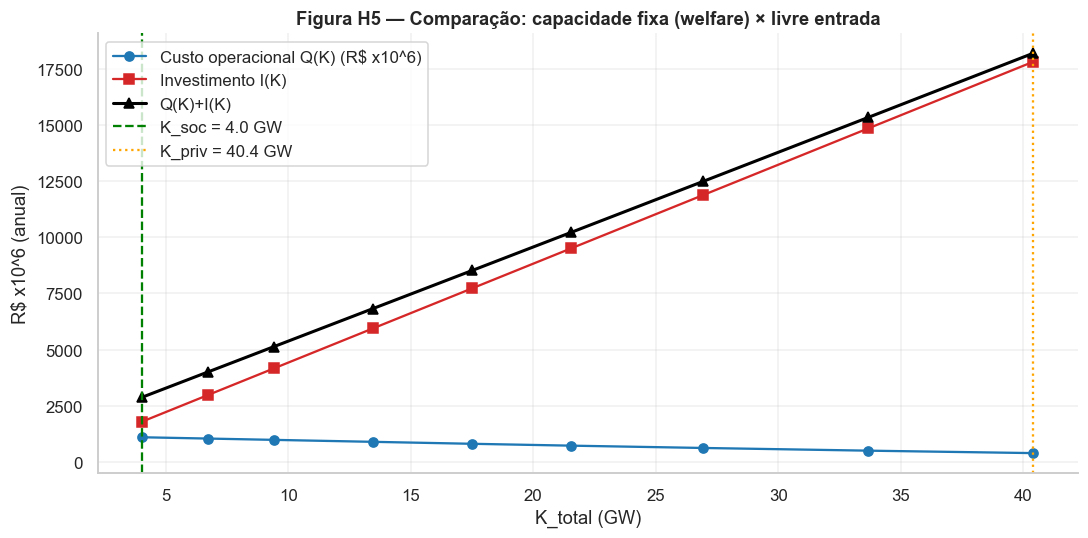

In [26]:
K_grid = np.array([0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0, 2.5, 3.0]) * K_TOT
rows = []
for K in K_grid:
    K_alloc = {s: K * (K_eff.loc[s, "K_s_eff_p99"] / K_TOT) for s in SUBSYS_ORDER}
    r = solve_alloc(K_alloc)
    rev_total = 0.0
    for s in SUBSYS_ORDER:
        lam = r["lambda_model"][s]
        rev_total += float((lam * a_s_l[s] * K_alloc[s]).sum()) * 365.0
    inv_total = sum(q_reg[s] * K_alloc[s] for s in SUBSYS_ORDER)
    rows.append({
        "K_total_GW": K/1000,
        "cost_op":    r["cost"],
        "inv_anual":  inv_total,
        "rev_anual":  rev_total,
        "margem_anual": rev_total - inv_total,
        "total_social": r["cost"] + inv_total,
    })
priv = pd.DataFrame(rows)
priv.to_csv(TABLES / "tab_investimento_K_grid.csv", index=False, float_format="%.4f")
print("Varredura de investimento (livre entrada vs welfare):")
print(priv.round(0).to_string(index=False))

K_soc_row = priv.loc[priv["total_social"].idxmin()]
K_soc = float(K_soc_row["K_total_GW"])
all_neg = (priv["margem_anual"] < 0).all()
if all_neg:
    K_priv = 0.0
    msg = "Margem privada negativa em todas as escalas testadas; livre entrada => K_priv = 0."
else:
    # Maior K com margem ainda não-negativa
    K_priv = float(priv.loc[priv["margem_anual"] >= 0, "K_total_GW"].max())
    msg = f"K_priv (maior K com margem >= 0) = {K_priv:.1f} GW."
print(f"\nK_soc (welfare) = {K_soc:.1f} GW")
print(msg)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(priv["K_total_GW"], priv["cost_op"]/1e6, "o-", color="#1f77b4", label="Custo operacional Q(K) (R$ x10^6)")
ax.plot(priv["K_total_GW"], priv["inv_anual"]/1e6, "s-", color="#d62728", label="Investimento I(K)")
ax.plot(priv["K_total_GW"], priv["total_social"]/1e6, "^-", color="black", lw=2, label="Q(K)+I(K)")
ax.axvline(K_soc,  color="green",  ls="--", label=f"K_soc = {K_soc:.1f} GW")
if K_priv > 0:
    ax.axvline(K_priv, color="orange", ls=":", label=f"K_priv = {K_priv:.1f} GW")
ax.set_xlabel("K_total (GW)"); ax.set_ylabel("R$ x10^6 (anual)")
ax.set_title("Figura H5 — Comparação: capacidade fixa (welfare) × livre entrada")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIGS / "fig_H5_social_vs_privado.png", bbox_inches="tight")
plt.show()


## 18. Apêndice B — métricas consolidadas

In [27]:
metrics = panel.groupby("id_subsistema").agg(
    CMO_obs_avg=("CMO_obs", "mean"),
    CMO_obs_p95=("CMO_obs", lambda x: float(np.nanpercentile(x.dropna(), 95))),
    PLD_hat_avg=("PLD_hat", "mean"),
    L_global_mean=("L_global", "mean"),
    L_global_max=("L_global", "max"),
    L_net_s_mean=("L_net_s", "mean"),
    G_s_total=("G_s_total", "sum"),
    G_w_total=("G_w_total", "sum"),
    G_h_total=("G_h_total", "sum"),
    Ramp_max_pos=("dL_res", "max"),
    Ramp_max_neg=("dL_res", "min"),
).reindex(SUBSYS_ORDER)

fc_cmo = (fcap.query("tag == 'F_capture_CMO'")
              .pivot_table(index="id_subsistema", columns="fonte", values="F_capture")
              .reindex(SUBSYS_ORDER))
metrics["F_capture_CMO_solar"] = fc_cmo["solar"]
metrics["F_capture_CMO_wind"]  = fc_cmo["wind"]

metrics.round(2).to_csv(TABLES / "tab_apendice_B_metricas.csv")
print("Apêndice B — métricas consolidadas (2025):")
print(metrics.round(2).to_string())


Apêndice B — métricas consolidadas (2025):
               CMO_obs_avg  CMO_obs_p95  PLD_hat_avg  L_global_mean  L_global_max  L_net_s_mean    G_s_total    G_w_total     G_h_total  Ramp_max_pos  Ramp_max_neg  F_capture_CMO_solar  F_capture_CMO_wind
id_subsistema                                                                                                                                                                                               
N                   139.84       340.35       166.19        8788.56      12204.28       8787.33      8742.14   1431912.89  5.930865e+07       1264.89      -1338.20                 0.66                1.36
NE                  126.96       333.64       156.53       14463.89      20156.18      12532.71  14130877.36  91130920.15  2.351121e+07       5893.64      -5682.43                 0.65                1.22
SE                  202.75       365.44       215.29       47489.67      73060.76      45808.34  12271937.51     41234.39  1.977570e+08  

## 19. Inventário final — figuras e tabelas salvas em `outputs/`

In [28]:
print("== Figuras geradas ==")
for p in sorted(FIGS.glob("*.png")):
    print(" -", p.relative_to(ROOT))
print()
print("== Tabelas geradas ==")
for p in sorted(TABLES.glob("*.csv")):
    print(" -", p.relative_to(ROOT))

inventory = {
    "figures": sorted([str(p.relative_to(ROOT)) for p in FIGS.glob("*.png")]),
    "tables":  sorted([str(p.relative_to(ROOT)) for p in TABLES.glob("*.csv")]),
}
(TABLES / "inventory.json").write_text(json.dumps(inventory, indent=2, ensure_ascii=False),
                                       encoding="utf-8")
print(f"\nInventário salvo em {TABLES / 'inventory.json'}")


== Figuras geradas ==
 - outputs\figures\fig01_carga_global_rb_res.png
 - outputs\figures\fig02_diagnostico_operacional.png
 - outputs\figures\fig04_curva_pato_contrafactual.png
 - outputs\figures\fig05_cmo_vs_Lnet.png
 - outputs\figures\fig06_hidrologia_proxy.png
 - outputs\figures\fig07_despacho_dia_tipico_SE.png
 - outputs\figures\fig09_situacional_sensibilidade.png
 - outputs\figures\fig12_iteracao_precos.png
 - outputs\figures\fig13_fator_captura.png
 - outputs\figures\fig18_valor_agua.png
 - outputs\figures\fig19_locacional_mfg.png
 - outputs\figures\fig_H5_social_vs_privado.png

== Tabelas geradas ==
 - outputs\tables\tab_alocacao_solar.csv
 - outputs\tables\tab_apendice_B_metricas.csv
 - outputs\tables\tab_capacidades_efetivas_p99.csv
 - outputs\tables\tab_coverage_data.csv
 - outputs\tables\tab_despacho_centralizado.csv
 - outputs\tables\tab_fator_captura.csv
 - outputs\tables\tab_investimento_K_grid.csv
 - outputs\tables\tab_locacional_equilibrio.csv
 - outputs\tables\tab_par

## Critério final — checklist

| Critério | Status |
| --- | --- |
| `L` para carga, `D` apenas como alias deprecated | ✅ |
| `L_RB`, `L_global`, `L_net_s`, `L_res`, `dL_res` definidos | ✅ |
| `CMO_obs`, `PLD_obs`, `PLD_hat`, `lambda_model` separados | ✅ |
| `F_capture_CMO`, `F_capture_PLD_obs`, `F_capture_PLD_hat` calculados | ✅ |
| `tab_coverage_data.csv` com período comum | ✅ |
| Capacidades `K_*_eff_p99` (proxy, não `K_*_inst`) | ✅ |
| Despacho com valor da água, orçamento e valor terminal | ✅ |
| Hidrologia marcada como **proxy** | ✅ |
| Modelo situacional: 2 solares + 1 térmica + 1 hidro; eólica exógena | ✅ |
| Sensibilidade ao tamanho do segundo agente solar | ✅ |
| Modelo locacional renomeado para *inspirado em MFG* | ✅ |
| Capacidade fixa vs livre entrada diferenciados | ✅ |
| Caminhos relativos via `Path.cwd()` (auto-detect) | ✅ |
| Inventário final de figuras e tabelas | ✅ |
